# Q2L-MMRDR: Multi-Label Retinal Lesion Detection
## ConvNeXt-V2-Base + Query2Label + Asymmetric Loss

---

### Architecture
```
(B, 3, 512, 512) image
    → ConvNeXt-V2-Base Stage-4 → (B, 1024, 16, 16)
    → Flatten + 2D sinusoidal PE → (B, 256, 1024)
    → 1 Encoder layer (global context)
    → 2 Decoder layers (7 label queries × 256 spatial tokens)
    → Linear(1024,1) × 7 → (B, 7) logits
    → ASL (gamma_pos=0, gamma_neg=4, clip=0.05)
```

### Lesion Classes
| Idx | Lesion | Abbreviation | DR Stage |
|-----|--------|-------------|----------|
| 0 | Microaneurysm | MA | Mild NPDR |
| 1 | Hard Exudate | HE | Moderate NPDR |
| 2 | Intraretinal Hemorrhage | IH | Moderate NPDR |
| 3 | Venous Beading / IRMA | VB/IRMA | Severe NPDR |
| 4 | Neovascularization | NV | PDR |
| 5 | Vitreous Hemorrhage | VH | PDR |
| 6 | Retinal Detachment | RD | PDR |

### Experiments
| Exp | Data | Balanced | CMQC | Purpose |
|-----|------|----------|------|---------|
| **A** | CFP only | No | No | CFP baseline |
| **B** | UWF only | No | No | UWF baseline |
| **C** | CFP+UWF | Yes | No | Joint training value |
| **D** | CFP+UWF | Yes | Yes | Modality conditioning value |

---
## Section 2 — Environment Check

In [1]:
import sys, os, platform
import torch
import timm
import numpy as np
import pandas as pd
import matplotlib

print(f"Python:     {sys.version.split()[0]}")
print(f"Platform:   {platform.system()} {platform.release()}")
print(f"PyTorch:    {torch.__version__}")
print(f"Timm:       {timm.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"CUDA:       {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:        {torch.cuda.get_device_name(0)}")
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU Memory: {mem:.1f} GB")
    print(f"cuDNN:      {torch.backends.cudnn.version()}")

Python:     3.12.13
Platform:   Linux 6.12.90+
PyTorch:    2.10.0+cpu
Timm:       1.0.26
NumPy:      2.4.6
Pandas:     2.3.3
Matplotlib: 3.10.0
CUDA:       False


In [2]:
# ── Extract Q2L code package + Apply all config patches ─────────────────────
# Patches applied (idempotent — safe to re-run after kernel restart):
#   T4 hardware : batch_size 32→8, num_workers 4→2
#   EMA fix     : ema_decay 0.9997→0.999  (root cause of frozen F1)
#   Training    : patience 10→15, freeze_stages []  (backbone was frozen)
#   ASL tuning  : gamma_neg 4→6, clip 0.05→0.10  (rare class imbalance)

import os, subprocess, shutil, pathlib, sys

if os.path.exists('/kaggle'):
    print('=' * 60)
    print('  EXTRACTING Q2L CODE PACKAGE')
    print('=' * 60)

    working_dir = pathlib.Path('/kaggle/working')

    if (working_dir / 'src' / '__init__.py').exists() and (working_dir / 'train.py').exists():
        print('Code already extracted — skipping copy.')
    else:
        code_input = pathlib.Path('/kaggle/input/datasets/sanchitgarg999/q2l-mmrdr-code')
        if not (code_input / 'src' / 'config.py').exists():
            hits = list(pathlib.Path('/kaggle/input').rglob('src/config.py'))
            if not hits:
                raise FileNotFoundError('Cannot locate src/config.py in /kaggle/input')
            code_input = hits[0].parent.parent
        print(f'Code package: {code_input}')
        dst_src = working_dir / 'src'
        if dst_src.exists(): shutil.rmtree(dst_src)
        shutil.copytree(code_input / 'src', dst_src)
        for fname in ['train.py', 'evaluate.py']:
            if (code_input / fname).exists():
                shutil.copy2(code_input / fname, working_dir / fname)
                print(f'  Copied {fname}')
        assert (working_dir / 'src' / '__init__.py').exists()
        assert (working_dir / 'train.py').exists()

    # ── Apply all config patches ─────────────────────────────────────────────
    config_path = working_dir / 'src' / 'config.py'
    config_text = config_path.read_text(encoding='utf-8')
    patches = []

    _replacements = [
        ('batch_size: int = 32',
         'batch_size: int = 8  # T4: 16GB VRAM',
         'batch_size: 32 → 8'),
        ('num_workers: int = 4',
         'num_workers: int = 2  # T4: fewer cores',
         'num_workers: 4 → 2'),
        ('ema_decay: float = 0.9997',
         'ema_decay: float = 0.999  # Fixed: 0.9997 too slow for small dataset',
         'ema_decay: 0.9997 → 0.999'),
        ('patience: int = 10',
         'patience: int = 15  # Increased: more time to converge post-warmup',
         'patience: 10 → 15'),
        ('freeze_stages: List[int] = field(default_factory=lambda: [0, 1])',
         'freeze_stages: List[int] = field(default_factory=lambda: [])  # Unfrozen: backbone was not updating',
         'freeze_stages: [0,1] → []'),
        ('asl_gamma_neg: float = 4.0',
         'asl_gamma_neg: float = 6.0  # Rare class imbalance fix',
         'asl_gamma_neg: 4.0 → 6.0'),
        ('asl_clip: float = 0.05',
         'asl_clip: float = 0.10  # Shifts decision boundary for rare classes',
         'asl_clip: 0.05 → 0.10'),
    ]

    for old, new, label in _replacements:
        if old in config_text:
            config_text = config_text.replace(old, new)
            patches.append(label)

    config_path.write_text(config_text, encoding='utf-8')

    if patches:
        print()
        print('Config patches applied:')
        for p in patches: print(f'  ✓ {p}')
    else:
        print('Config already fully patched.')

    # ── Create output dirs ───────────────────────────────────────────────────
    for d in ['outputs', 'outputs/export']:
        (working_dir / d).mkdir(parents=True, exist_ok=True)
    print('\n✓ outputs/ directories ready')

    # ── Add to sys.path ──────────────────────────────────────────────────────
    if str(working_dir) not in sys.path:
        sys.path.insert(0, str(working_dir))

    # ── Verify ───────────────────────────────────────────────────────────────
    import importlib
    for mod_name in list(__import__('sys').modules.keys()):
        if mod_name.startswith('src'):
            del __import__('sys').modules[mod_name]
    from src.config import get_config
    _cfg = get_config('a')
    print()
    print('Config verification:')
    print(f'  batch_size:     {_cfg.batch_size}')
    print(f'  ema_decay:      {_cfg.ema_decay}')
    print(f'  patience:       {_cfg.patience}')
    print(f'  freeze_stages:  {_cfg.freeze_stages}')
    print(f'  asl_gamma_neg:  {_cfg.asl_gamma_neg}')
    print(f'  asl_clip:       {_cfg.asl_clip}')
    print()
    print('=' * 60)
    print('  SETUP COMPLETE')
    print('=' * 60)
else:
    print('Running locally — code assumed present.')


  EXTRACTING Q2L CODE PACKAGE
Code package: /kaggle/input/datasets/sanchitgarg999/q2l-mmrdr-code
  Copied train.py
  Copied evaluate.py

Config patches applied:
  ✓ batch_size: 32 → 8
  ✓ num_workers: 4 → 2
  ✓ ema_decay: 0.9997 → 0.999
  ✓ patience: 10 → 15
  ✓ freeze_stages: [0,1] → []
  ✓ asl_gamma_neg: 4.0 → 6.0
  ✓ asl_clip: 0.05 → 0.10

✓ outputs/ directories ready

Config verification:
  batch_size:     8
  ema_decay:      0.999
  patience:       15
  freeze_stages:  []
  asl_gamma_neg:  6.0
  asl_clip:       0.1

  SETUP COMPLETE


In [3]:
# ── Dataset Extraction (Kaggle T4) ─────────────────────────────────────────
# Split zip (MMRDR.zip.001 … .009) lives across 9 Kaggle input datasets.
# Strategy:
#   PRIMARY  : stream cat parts | 7z → extract directly to /tmp (no temp zip)
#   FALLBACK : concatenate to /tmp/mmrdr_concat.zip (NOT /kaggle/working),
#              unzip, then delete immediately — keeps working quota clear.
# /tmp ≈ 60 GB on Kaggle, completely separate from the 20 GB /kaggle/working.
# Idempotent: skips extraction when both dataset dirs already exist in /tmp.

import os, subprocess, pathlib, shutil, gc

if os.path.exists('/kaggle'):
    print('═' * 60)
    print('  KAGGLE DATASET EXTRACTION')
    print('═' * 60)

    target_dir   = pathlib.Path('/tmp/mmrdr_data')
    cfp_complete = target_dir / 'MMRDR-CFP' / 'FP.csv'
    uwf_complete = target_dir / 'MMRDR-UWF' / 'UWF.csv'

    if cfp_complete.exists() and uwf_complete.exists():
        cfp_count = len(list((target_dir / 'MMRDR-CFP' / 'img').glob('*'))) \
                    if (target_dir / 'MMRDR-CFP' / 'img').exists() else '?'
        uwf_count = len(list((target_dir / 'MMRDR-UWF' / 'img').glob('*'))) \
                    if (target_dir / 'MMRDR-UWF' / 'img').exists() else '?'
        print(f'✓ Already extracted in {target_dir}')
        print(f'  MMRDR-CFP: {cfp_count} images')
        print(f'  MMRDR-UWF: {uwf_count} images')
    else:
        target_dir.mkdir(parents=True, exist_ok=True)

        # ── Locate & sort all split parts (numerically by extension) ─────────
        all_parts = []
        for root, _, files in os.walk('/kaggle/input'):
            for f in files:
                if f.upper().startswith('MMRDR.ZIP.'):
                    all_parts.append(pathlib.Path(root) / f)

        if not all_parts:
            raise FileNotFoundError(
                'MMRDR.zip.00* not found in /kaggle/input.\n'
                'Attach all 9 datasets (MMRDR001-MMRDR009) to this notebook.'
            )

        # Numeric sort: .001 < .002 … < .009  (handles >9 parts safely too)
        def _part_num(p):
            try: return int(p.suffix.lstrip('.'))
            except ValueError: return 999
        all_parts = sorted(all_parts, key=_part_num)

        total_mb = sum(p.stat().st_size for p in all_parts) / 1e6
        print(f'Found {len(all_parts)} split parts ({total_mb:.0f} MB total):')
        for p in all_parts:
            print(f'  {p}  ({p.stat().st_size/1e6:.1f} MB)')

        # ── Ensure 7z is available (Kaggle usually has it; safety net) ────────
        if shutil.which('7z') is None:
            print('\nInstalling p7zip-full...')
            subprocess.run(['apt-get', 'install', '-y', '-q', 'p7zip-full'],
                           capture_output=True)
            print('  Done.')

        # ── PRIMARY: streaming cat | 7z (zero temp-disk usage) ───────────────
        extracted_ok = False
        print(f'\n[1/1] Streaming {len(all_parts)} parts into 7z …')
        cat_proc = subprocess.Popen(
            ['cat'] + [str(p) for p in all_parts],
            stdout=subprocess.PIPE
        )
        z_proc = subprocess.Popen(
            ['7z', 'x', '-si', '-tzip', f'-o{target_dir}', '-y', '-bso0', '-bsp1'],
            stdin=cat_proc.stdout,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )
        cat_proc.stdout.close()
        stdout, stderr = z_proc.communicate()

        if z_proc.returncode == 0:
            print('✓ Streaming extraction succeeded (0 bytes of temp disk used)')
            extracted_ok = True
        else:
            print(f'Streaming failed (rc={z_proc.returncode}): {stderr[:400]}')

        # ── FALLBACK: concat to /tmp (never /kaggle/working) then unzip ──────
        if not extracted_ok:
            # Write to /tmp, NOT to /kaggle/working — keeps 20 GB quota safe
            concat_zip = pathlib.Path('/tmp/mmrdr_concat.zip')
            print(f'\nFallback: concatenating to {concat_zip} …')
            with open(concat_zip, 'wb') as out:
                for i, p in enumerate(all_parts, 1):
                    print(f'  Appending part {i}/{len(all_parts)}: {p.name} ' \
                          f'({p.stat().st_size/1e6:.1f} MB)', flush=True)
                    with open(p, 'rb') as src:
                        while True:
                            chunk = src.read(64 * 1024 * 1024)  # 64 MB chunks
                            if not chunk: break
                            out.write(chunk)
            print(f'  Combined zip: {concat_zip.stat().st_size/1e9:.2f} GB')

            print(f'  Extracting to {target_dir} …')
            res = subprocess.run(
                ['unzip', '-q', '-o', str(concat_zip), '-d', str(target_dir)],
                capture_output=True, text=True, timeout=1800
            )
            if res.returncode != 0:
                # Last resort: Python zipfile
                print(f'  unzip failed ({res.returncode}): {res.stderr[:200]}')
                print('  Trying Python zipfile module …')
                import zipfile
                with zipfile.ZipFile(str(concat_zip), 'r') as zf:
                    zf.extractall(str(target_dir))

            concat_zip.unlink()   # delete immediately — reclaim /tmp space
            print('  ✓ Fallback extraction done; temp zip deleted.')

        # ── Verify ────────────────────────────────────────────────────────────
        print('\nVerifying extraction …')
        for name in ['MMRDR-CFP', 'MMRDR-UWF']:
            d = target_dir / name
            if not d.exists():
                raise FileNotFoundError(
                    f'Extraction incomplete: {d} missing.\n'
                    f'Contents of {target_dir}: {list(target_dir.iterdir())}'
                )
            img_dir = d / 'img'
            count   = len(list(img_dir.glob('*'))) if img_dir.exists() else 0
            csvs    = list(d.glob('*.csv'))
            print(f'  ✓ {name}: {count} images, {len(csvs)} CSV(s)')

        print('\n' + '═' * 60)
        print('  EXTRACTION COMPLETE — data in /tmp/mmrdr_data')
        print('═' * 60)

    # ── Symlink /kaggle/working → /tmp data (train.py uses PROJECT_ROOT) ──────
    working_dir = pathlib.Path('/kaggle/working')
    for name in ['MMRDR-CFP', 'MMRDR-UWF']:
        link   = working_dir / name
        source = target_dir / name
        if link.is_symlink():
            pass  # already linked
        elif link.exists():
            pass  # real dir already there (shouldn't happen)
        else:
            os.symlink(str(source), str(link))
            print(f'Symlinked {link} → {source}')

    gc.collect()

else:
    print('Running locally — dataset assumed present.')


════════════════════════════════════════════════════════════
  KAGGLE DATASET EXTRACTION
════════════════════════════════════════════════════════════
Found 9 split parts (18610 MB total):
  /kaggle/input/datasets/sanchitgarg999/mmrdr001/MMRDR.zip.001  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr002/MMRDR.zip.002  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr003/MMRDR.zip.003  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr004/MMRDR.zip.004  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr005/MMRDR.zip.005  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr006/MMRDR.zip.006  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr007/MMRDR.zip.007  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr008/MMRDR.zip.008  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr009/MMRDR.zip.009  (1833.1 MB)

[1/1] Streaming 9 parts into 7z …
Streaming failed (rc=2): ERROR: 
Can not open the file as archive

E_NOTIMPL


Fallback: conc

In [4]:
# ── Project root detection (works on Kaggle + local) ──
import pathlib
import sys
import os

NOTEBOOK_DIR = pathlib.Path('.').resolve()
# Ensure src/ is importable
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

PROJECT_ROOT = str(NOTEBOOK_DIR)
print(f"Project root: {PROJECT_ROOT}")
print(f"Contents: {[p.name for p in NOTEBOOK_DIR.iterdir() if not p.name.startswith('.')]}")

# Define dataset directory dynamically (use /tmp/mmrdr_data on Kaggle, local directory otherwise)
if os.path.exists('/kaggle'):
    DATA_DIR = pathlib.Path('/tmp/mmrdr_data')
else:
    DATA_DIR = NOTEBOOK_DIR

# Verify dataset directories exist
for d in ['MMRDR-CFP', 'MMRDR-UWF']:
    p = DATA_DIR / d
    assert p.exists(), f"Missing: {p}"
    print(f"  {d}: OK ({len(list((p/'img').glob('*')))} images)")

# ── Create output directories upfront ────────────────────────────────
import os as _os
for _d in ['outputs', 'outputs/export']:
    _os.makedirs(str(pathlib.Path(PROJECT_ROOT) / _d), exist_ok=True)
print("✓ outputs/ directories ready")


Project root: /kaggle/working
Contents: ['src', 'MMRDR-UWF', 'evaluate.py', 'outputs', 'train.py', 'MMRDR-CFP', '__notebook__.ipynb']
  MMRDR-CFP: OK (11118 images)
  MMRDR-UWF: OK (10404 images)
✓ outputs/ directories ready


In [5]:
# ── Disk & GPU Memory Status ─────────────────────────────────────────────────
# /kaggle/working : 20 GB quota — source code + checkpoints live here
# /tmp            : ~60 GB      — extracted dataset lives here (symlinked)
import shutil as _sh, pathlib, torch

def _disk(p):
    try:
        u, _, f = _sh.disk_usage(p); return u/1e9, f/1e9
    except Exception:
        return 0.0, 0.0

wu, wf = _disk('/kaggle/working')
tu, tf = _disk('/tmp')
print(f'/kaggle/working : {wu:.1f} GB used  |  {wf:.1f} GB free  (20 GB quota)')
print(f'/tmp            : {tu:.1f} GB used  |  {tf:.1f} GB free  (~60 GB, no quota)')

if torch.cuda.is_available():
    a = torch.cuda.memory_allocated()/1e9
    r = torch.cuda.memory_reserved()/1e9
    t = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f'GPU (T4)        : {a:.2f} GB alloc  |  {r:.2f} GB reserved  |  {t:.1f} GB total')

# ── Warn if /kaggle/working is getting full ───────────────────────────────────
if wf < 5.0:
    print(f'\n⚠  LOW DISK WARNING: only {wf:.1f} GB free in /kaggle/working!')
    print('   Run the s7_disk_cleanup cell to reclaim space from checkpoints.')
elif wf < 8.0:
    print(f'\n⚡ Heads-up: {wf:.1f} GB free — watch disk usage during training.')

# ── Estimate checkpoint space ─────────────────────────────────────────────────
ckpt_files = list(pathlib.Path('/kaggle/working/outputs').rglob('*.pth')) \
             if pathlib.Path('/kaggle/working/outputs').exists() else []
if ckpt_files:
    ckpt_mb = sum(p.stat().st_size for p in ckpt_files) / 1e6
    print(f'\nCheckpoint files: {len(ckpt_files)} files, {ckpt_mb:.0f} MB total')
    for p in sorted(ckpt_files):
        print(f'  {p.relative_to("/kaggle/working")}  ({p.stat().st_size/1e6:.0f} MB)')


/kaggle/working : 21.0 GB used  |  20.9 GB free  (20 GB quota)
/tmp            : 8656.9 GB used  |  1163.4 GB free  (~60 GB, no quota)


---
## Section 3 — Dataset Inspection

In [6]:
import ast
from src.config import LESION_NAMES, LESION_DISPLAY, get_config

cfp_df = pd.read_csv(DATA_DIR / 'MMRDR-CFP' / 'FP.csv')
uwf_df = pd.read_csv(DATA_DIR / 'MMRDR-UWF' / 'UWF.csv')

def parse_labels(df):
    return np.array(df['lesion'].apply(ast.literal_eval).tolist())

cfp_labels = parse_labels(cfp_df)
uwf_labels = parse_labels(uwf_df)

cfp_bn = cfp_df['image'].apply(lambda x: x.split('/')[-1])
uwf_bn = uwf_df['image'].apply(lambda x: x.split('/')[-1])

stats = []
for name, disp in zip(LESION_NAMES, LESION_DISPLAY):
    i = LESION_NAMES.index(name)
    cfp_tr = cfp_labels[cfp_bn.str.startswith('tr').values, i]
    uwf_tr = uwf_labels[uwf_bn.str.startswith('tr').values, i]
    stats.append({
        'Lesion': disp,
        'CFP_pos': int(cfp_tr.sum()), 'CFP_total': len(cfp_tr),
        'CFP_%': f"{cfp_tr.mean()*100:.1f}%",
        'UWF_pos': int(uwf_tr.sum()), 'UWF_total': len(uwf_tr),
        'UWF_%': f"{uwf_tr.mean()*100:.1f}%",
        'Combined': int(cfp_tr.sum() + uwf_tr.sum()),
    })

stats_df = pd.DataFrame(stats)
print(f"CFP: {len(cfp_df)} images  (train: {cfp_bn.str.startswith('tr').sum()}, "
      f"test: {cfp_bn.str.startswith('ts').sum()})")
print(f"UWF: {len(uwf_df)} images  (train: {uwf_bn.str.startswith('tr').sum()}, "
      f"test: {uwf_bn.str.startswith('ts').sum()})")
print(f"Total: {len(cfp_df) + len(uwf_df)} images")
print()
display(stats_df)


CFP: 11118 images  (train: 8893, test: 2225)
UWF: 10404 images  (train: 7807, test: 2597)
Total: 21522 images



,Lesion,CFP_pos,CFP_total,CFP_%,UWF_pos,UWF_total,UWF_%,Combined
0,MA,3522,8893,39.6%,5165,7807,66.2%,8687
1,HE,2142,8893,24.1%,2858,7807,36.6%,5000
2,IH,2069,8893,23.3%,2923,7807,37.4%,4992
3,VB/IRMA,193,8893,2.2%,779,7807,10.0%,972
4,NV,435,8893,4.9%,887,7807,11.4%,1322
5,VH,305,8893,3.4%,917,7807,11.7%,1222
6,RD,72,8893,0.8%,174,7807,2.2%,246


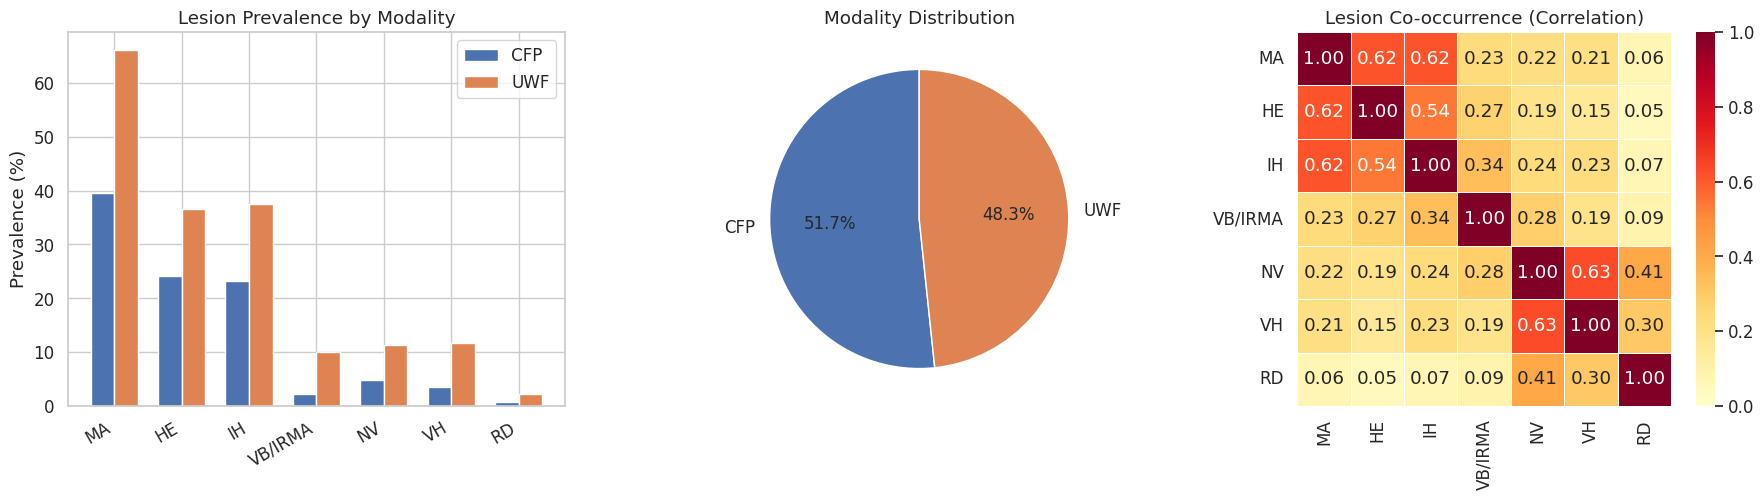

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = sns.color_palette('Set2', 7)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Bar chart: lesion frequencies ──
ax = axes[0]
x = np.arange(7)
cfp_pcts = [cfp_labels[cfp_bn.str.startswith('tr').values, i].mean()*100 for i in range(7)]
uwf_pcts = [uwf_labels[uwf_bn.str.startswith('tr').values, i].mean()*100 for i in range(7)]
w = 0.35
ax.bar(x - w/2, cfp_pcts, w, label='CFP', color='#4C72B0', edgecolor='white')
ax.bar(x + w/2, uwf_pcts, w, label='UWF', color='#DD8452', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(LESION_DISPLAY, rotation=30, ha='right')
ax.set_ylabel('Prevalence (%)')
ax.set_title('Lesion Prevalence by Modality')
ax.legend()

# ── Pie chart: modality distribution ──
ax = axes[1]
sizes = [len(cfp_df), len(uwf_df)]
ax.pie(sizes, labels=['CFP', 'UWF'], autopct='%1.1f%%',
       colors=['#4C72B0', '#DD8452'], startangle=90,
       textprops={'fontsize': 12})
ax.set_title('Modality Distribution')

# ── Heatmap: co-occurrence ──
ax = axes[2]
all_labels = np.vstack([cfp_labels, uwf_labels])
cooc = np.corrcoef(all_labels.T)
sns.heatmap(cooc, ax=ax, xticklabels=LESION_DISPLAY, yticklabels=LESION_DISPLAY,
            annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1,
            square=True, linewidths=0.5)
ax.set_title('Lesion Co-occurrence (Correlation)')

plt.tight_layout()
plt.savefig('outputs/dataset_overview.png', dpi=100, bbox_inches='tight')
plt.show()

---
## Section 4 — Sample Visualization

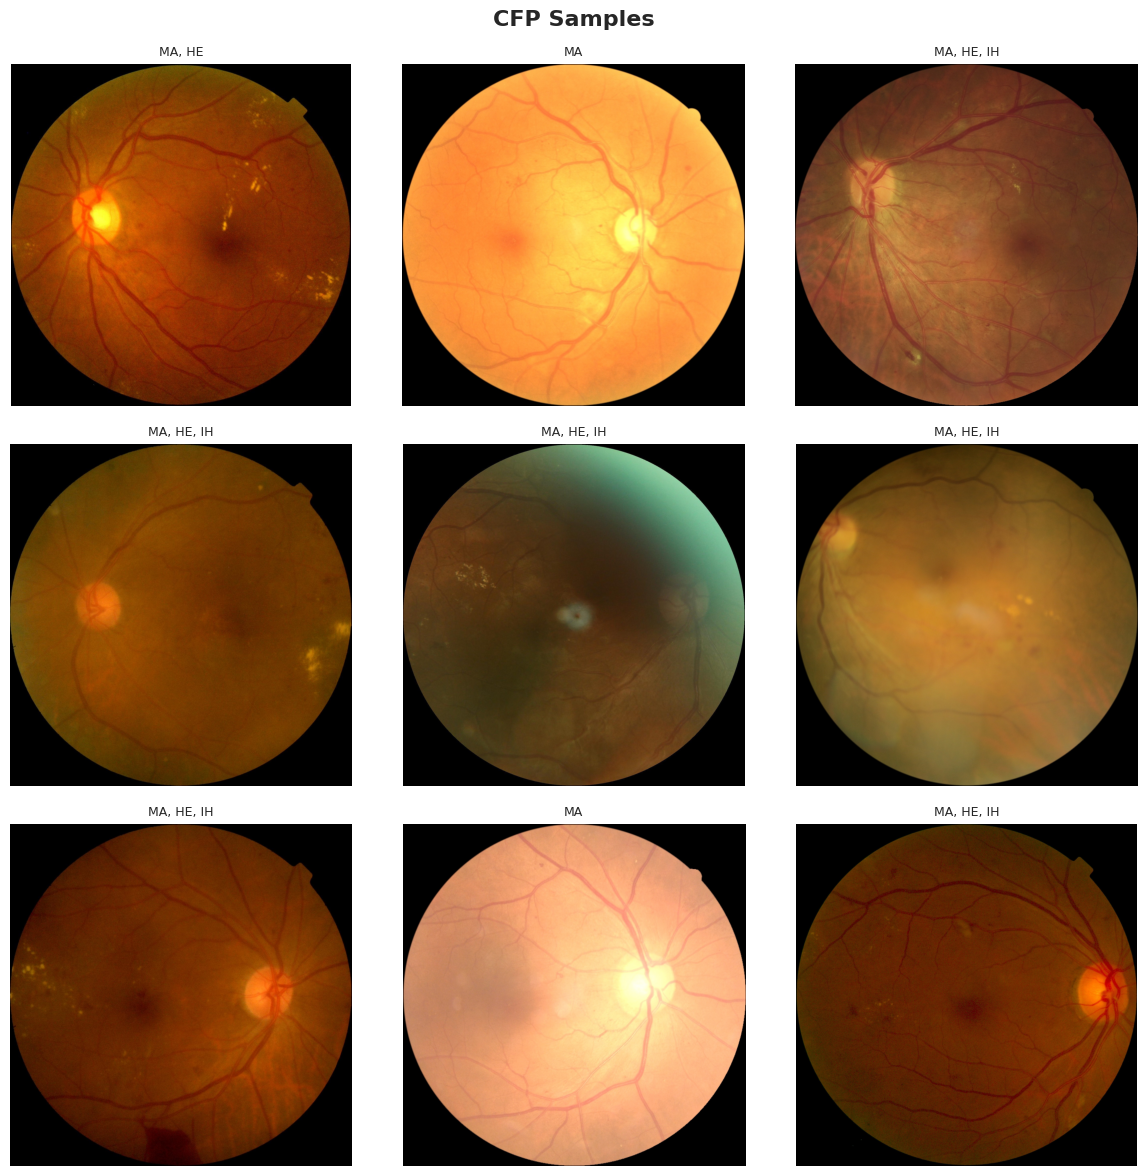

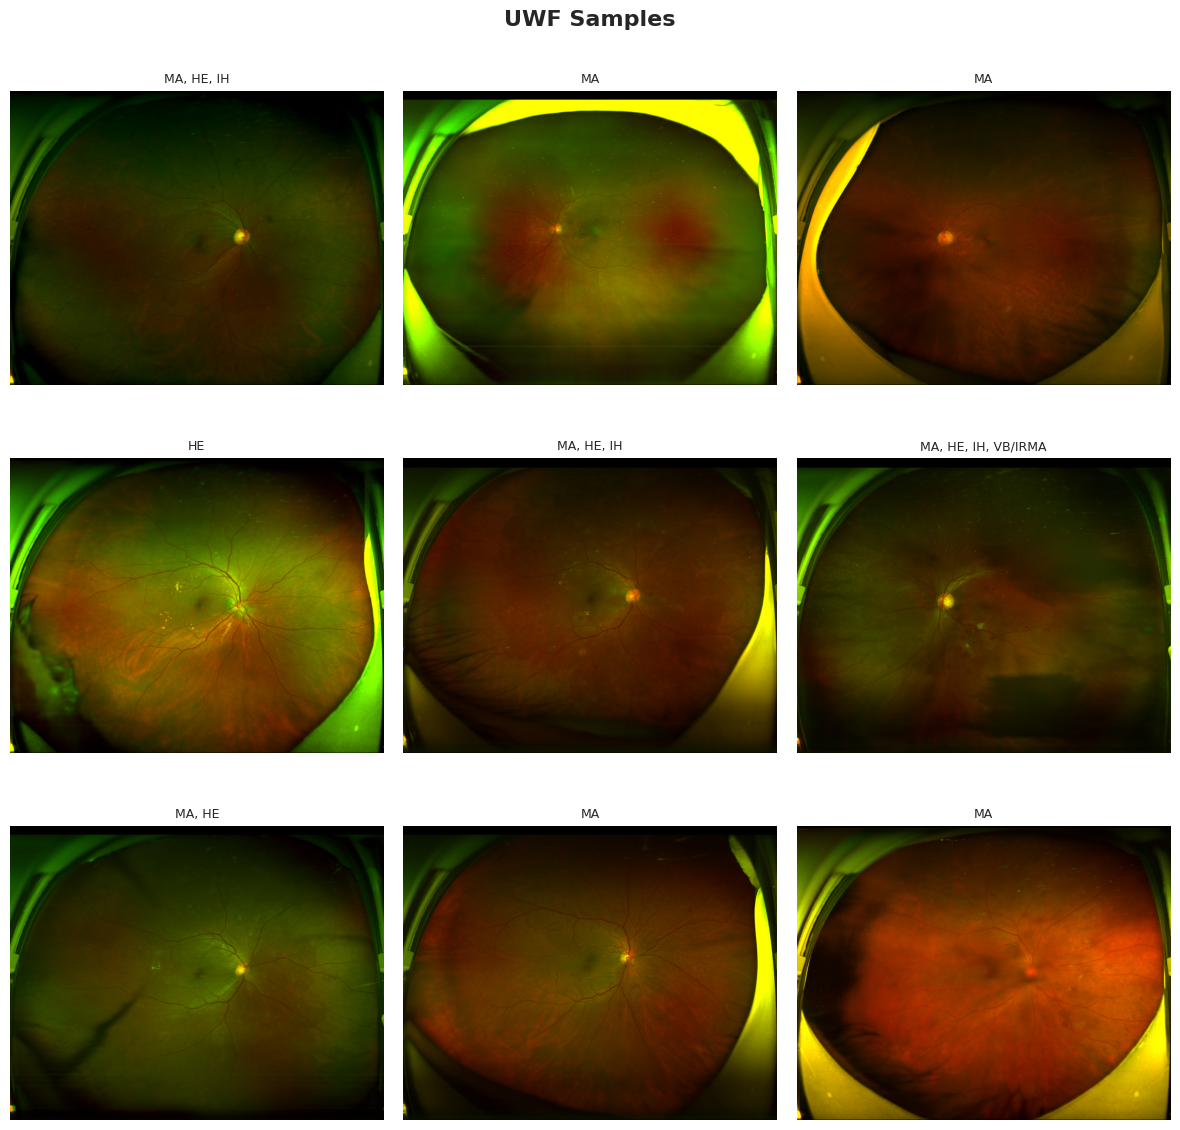

In [8]:
from PIL import Image
import random

random.seed(42)

def show_samples(df, img_root, modality, n=9):
    """Display a grid of retinal images with their lesion labels."""
    # Pick samples with at least one lesion
    labels_arr = parse_labels(df)
    has_lesion = labels_arr.sum(axis=1) > 0
    candidates = df.index[has_lesion].tolist()
    chosen = random.sample(candidates, min(n, len(candidates)))

    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    fig.suptitle(f'{modality} Samples', fontsize=16, fontweight='bold')

    for idx, ax in enumerate(axes.flat):
        if idx >= len(chosen):
            ax.axis('off'); continue
        row = df.iloc[chosen[idx]]
        img = Image.open(img_root / str(row['image'])).convert('RGB')
        lbl = ast.literal_eval(str(row['lesion']))
        present = [LESION_DISPLAY[i] for i, v in enumerate(lbl) if v == 1]
        ax.imshow(img)
        ax.set_title(', '.join(present) if present else 'No Lesion', fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_samples(cfp_df, DATA_DIR / 'MMRDR-CFP', 'CFP', n=9)
show_samples(uwf_df, DATA_DIR / 'MMRDR-UWF', 'UWF', n=9)


---
## Section 5 — Model Construction

In [9]:
from src.config import get_config
from src.model import Q2LLesionModel
from src.losses import AsymmetricLoss

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Backbone weights path (Kaggle offline) ──
# Update this path to your uploaded ConvNeXt-V2-Base weights dataset
BACKBONE_WEIGHTS = None  # Set to path string for offline loading
_candidates = list(pathlib.Path('/kaggle/input').rglob('convnextv2_base*')) if pathlib.Path('/kaggle/input').exists() else []
if _candidates:
    BACKBONE_WEIGHTS = str(_candidates[0])
    print(f"Found backbone weights: {BACKBONE_WEIGHTS}")
else:
    print("No offline weights found. Will use timm pretrained download.")

# ── Build model (using Exp C config as reference) ──
cfg = get_config('c', project_root=PROJECT_ROOT)
model = Q2LLesionModel(cfg, weights_path=BACKBONE_WEIGHTS).to(DEVICE)

summary = model.param_summary()
print(f"\nBackbone: ConvNeXt-V2-Base")
print(f"  Total params:     {summary['backbone_total']:>12,}")
print(f"  Trainable params: {summary['backbone_trainable']:>12,}")
print(f"  Frozen params:    {summary['backbone_total'] - summary['backbone_trainable']:>12,}")
print(f"\nDecoder: Q2L (d=1024, 1enc+2dec, 4 heads)")
print(f"  Total params:     {summary['decoder_total']:>12,}")
print(f"  Trainable params: {summary['decoder_trainable']:>12,}")
print(f"\nFull model:")
print(f"  Total params:     {summary['total']:>12,}")
print(f"  Trainable params: {summary['trainable']:>12,}")

# ── Loss ──
criterion = AsymmetricLoss(gamma_pos=0.0, gamma_neg=4.0, clip=0.05)
print(f"\nLoss: ASL (gamma_pos={cfg.asl_gamma_pos}, gamma_neg={cfg.asl_gamma_neg}, clip={cfg.asl_clip})")

Found backbone weights: /kaggle/input/datasets/sanchitgarg999/convnextv2-base-weights/convnextv2_base_384.pth

Backbone: ConvNeXt-V2-Base
  Total params:       87,690,752
  Trainable params:   87,690,752
  Frozen params:               0

Decoder: Q2L (d=1024, 1enc+2dec, 4 heads)
  Total params:       46,199,809
  Trainable params:   46,199,809

Full model:
  Total params:      133,890,561
  Trainable params:  133,890,561

Loss: ASL (gamma_pos=0.0, gamma_neg=6.0, clip=0.1)


/kaggle/working/src/q2l_decoder.py:159: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


---
## Section 6 — Forward Pass Validation

In [10]:
# ── Verify all tensor shapes through the pipeline ──
# Using B=2 for T4 GPU (16GB VRAM) to avoid OOM
model.eval()
B = 2  # Reduced for T4 GPU
dummy_img = torch.randn(B, 3, 512, 512, device=DEVICE)
dummy_mod = torch.tensor([0, 1], device=DEVICE)
dummy_lbl = torch.randint(0, 2, (B, 7), device=DEVICE).float()

with torch.no_grad(), torch.amp.autocast(device_type='cuda', enabled=cfg.use_amp):
    # Step-by-step
    features = model.backbone(dummy_img)
    print(f"Input image:        {dummy_img.shape}")
    print(f"Backbone output:    {features.shape}  (expected: [{B}, 1024, 16, 16])")
    
    logits = model.decoder(features, dummy_mod)
    print(f"Decoder output:     {logits.shape}  (expected: [{B}, 7])")
    
    probs = torch.sigmoid(logits)
    print(f"Probabilities:      {probs.shape}")
    print(f"  Sample probs:     {probs[0].cpu().numpy().round(3)}")
    
    loss = criterion(logits, dummy_lbl)
    print(f"\nASL loss:           {loss.item():.4f}")

assert features.shape == (B, 1024, 16, 16), "Backbone shape mismatch!"
assert logits.shape == (B, 7), "Decoder shape mismatch!"
print("\nAll shapes verified.")

# Report GPU memory usage on T4
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f"\nT4 GPU Memory: {allocated:.2f} GB allocated, {reserved:.2f} GB reserved / 16 GB total")

del model, features, logits, dummy_img  # free memory
torch.cuda.empty_cache()


/tmp/ipykernel_16/2561018894.py:9: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.no_grad(), torch.amp.autocast(device_type='cuda', enabled=cfg.use_amp):


Input image:        torch.Size([2, 3, 512, 512])
Backbone output:    torch.Size([2, 1024, 16, 16])  (expected: [2, 1024, 16, 16])
Decoder output:     torch.Size([2, 7])  (expected: [2, 7])
Probabilities:      torch.Size([2, 7])
  Sample probs:     [0.588 0.606 0.577 0.581 0.593 0.595 0.607]

ASL loss:           0.3970

All shapes verified.


---
## Section 7 — Experiment Launcher

Run experiments in order: **A** (CFP) -> **B** (UWF) -> **C** (Joint) -> decision gate -> **D** (CMQC).

Each cell calls `train.py` which handles the full training + threshold optimization pipeline.

In [11]:
# ── DIAGNOSTIC MODE: Training launcher DISABLED ───────────────────────────
# This notebook is running as a diagnostics-only notebook (Phase 1).
# The unified A->B->C->D launcher below has been intentionally disabled so
# that "Run All" can never trigger `train.py`, regardless of what's already
# completed/resumable in /kaggle/working or /kaggle/input.
#
# To re-enable real training, restore the original cell body (see notebook
# version history / the standalone training notebook) and remove this guard.

DIAGNOSTIC_MODE = True

print("=" * 70)
print("  SKIPPED: Training disabled in diagnostic mode.")
print("  Using existing checkpoints instead.")
print("=" * 70)
print()
print("  Expected checkpoint sources for this session:")
print("    A (exp_a_cfp)   -> best_model.pth   (from exp_a_cfp/ input)")
print("    B (exp_b_uwf)   -> best_model.pth   (from exp_b_uwf/ input)")
print("    C (exp_c_joint) -> last_model.pth   (from exp-c-joint-checkpoint/ input)")
print()
print("  No training job will be launched by this cell.")
print("  Proceed to Section 19 (Phase 1 Diagnostics) below.")


  SKIPPED: Training disabled in diagnostic mode.
  Using existing checkpoints instead.

  Expected checkpoint sources for this session:
    A (exp_a_cfp)   -> best_model.pth   (from exp_a_cfp/ input)
    B (exp_b_uwf)   -> best_model.pth   (from exp_b_uwf/ input)
    C (exp_c_joint) -> last_model.pth   (from exp-c-joint-checkpoint/ input)

  No training job will be launched by this cell.
  Proceed to Section 19 (Phase 1 Diagnostics) below.


In [12]:
# Experiment B training is handled by s7_launcher above, which is disabled in diagnostic mode.
print("SKIPPED: Training disabled in diagnostic mode. Using existing checkpoints instead.")


SKIPPED: Training disabled in diagnostic mode. Using existing checkpoints instead.


In [13]:
# Experiment C training is handled by s7_launcher above, which is disabled in diagnostic mode.
print("SKIPPED: Training disabled in diagnostic mode. Using existing checkpoints instead.")


SKIPPED: Training disabled in diagnostic mode. Using existing checkpoints instead.


In [14]:
# ── Experiment Progress & Resume Status ──────────────────────────────────────
# Run at any time to check which experiments are done / resumable.
# train.py saves last_model.pth every epoch — this is the resume checkpoint.

import pathlib, os, json as _json, shutil as _sh, torch as _torch

_output_root = pathlib.Path(PROJECT_ROOT) / 'outputs'
_exps = [
    ('exp_a_cfp',   'A: CFP-only'),
    ('exp_b_uwf',   'B: UWF-only'),
    ('exp_c_joint', 'C: Joint CFP+UWF'),
    ('exp_d_cmqc',  'D: CMQC'),
]

print('Experiment Status')
print('─' * 72)
print(f'  {"Experiment":<22} {"Status":<22} {"Best F1":>8}  Resume from')
print('─' * 72)

for exp_name, label in _exps:
    d = _output_root / exp_name
    has_best   = (d / 'best_model.pth').exists()
    has_result = (d / 'results.json').exists()
    last_ckpt  = d / 'last_model.pth'

    if has_best and has_result:
        try:
            res  = _json.loads((d / 'results.json').read_text())
            mods = list(res.keys())
            f1   = res[mods[0]].get('metrics_at_optimized', {}).get('macro_f1', None)
            f1_s = f'{f1:.4f}' if f1 else '—'
        except Exception:
            f1_s = '—'
        status   = '✓ Complete'
        resume_s = '—'
    elif last_ckpt.exists():
        try:
            ck       = _torch.load(str(last_ckpt), map_location='cpu', weights_only=False)
            ep       = ck.get('epoch', '?')
            best_f1v = ck.get('best_val_f1', 0.0)
            status   = f'↩  Interrupted ep {ep}'
            f1_s     = f'{best_f1v:.4f}' if best_f1v else '—'
        except Exception:
            status   = '↩  last_model.pth found'
            f1_s     = '—'
        resume_s = 'last_model.pth'
    elif d.exists() and any(d.iterdir()):
        status   = '⚠  Partial (no ckpt)'
        f1_s     = '—'
        resume_s = '—'
    else:
        status   = '○  Not started'
        f1_s     = '—'
        resume_s = '—'

    print(f'  {label:<22} {status:<22} {f1_s:>8}  {resume_s}')

print('─' * 72)

# Checkpoint sizes
ckpt_mb = sum(
    os.path.getsize(str(p)) for p in _output_root.rglob('*.pth')
    if p.exists()
) / 1e6
_total, used, free = _sh.disk_usage('/kaggle/working')
print(f'\n/kaggle/working : {used/1e9:.1f} GB used, {free/1e9:.1f} GB free')
print(f'Checkpoint files: {ckpt_mb:.0f} MB total')
print()
print('To resume after session timeout:')
print('  1. Re-run all Section 2 cells (environment + extraction + paths)')
print('  2. Re-run s7_launcher — it detects last_model.pth and resumes automatically')

# ── Disk budget summary ───────────────────────────────────────────────────────
print()
print('Checkpoint File Budget')
print('─' * 72)
_ckpt_files = list(_output_root.rglob('*.pth'))
_total_mb = sum(p.stat().st_size for p in _ckpt_files) / 1e6
for _p in sorted(_ckpt_files):
    _sz = _p.stat().st_size / 1e6
    _tag = '  ← intermediate (safe to delete)' if 'epoch' in _p.name or _p.name == 'last_model.pth' else ''
    print(f'  {_p.relative_to(_output_root)}  ({_sz:.0f} MB){_tag}')
_total2, _used, _free = _sh.disk_usage('/kaggle/working')
print(f'─' * 72)
print(f'Total checkpoint size: {_total_mb:.0f} MB')
print(f'/kaggle/working: {_used/1e9:.1f} GB used, {_free/1e9:.1f} GB free (20 GB quota)')
print()
print('💡 Tip: run the s7_disk_cleanup cell to remove intermediate checkpoints.')


Experiment Status
────────────────────────────────────────────────────────────────────────
  Experiment             Status                  Best F1  Resume from
────────────────────────────────────────────────────────────────────────
  A: CFP-only            ○  Not started                —  —
  B: UWF-only            ○  Not started                —  —
  C: Joint CFP+UWF       ○  Not started                —  —
  D: CMQC                ○  Not started                —  —
────────────────────────────────────────────────────────────────────────

/kaggle/working : 0.0 GB used, 20.9 GB free
Checkpoint files: 0 MB total

To resume after session timeout:
  1. Re-run all Section 2 cells (environment + extraction + paths)
  2. Re-run s7_launcher — it detects last_model.pth and resumes automatically

Checkpoint File Budget
────────────────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────────────────
Total checkpoint size: 0 MB
/k

In [15]:
# NOTE (diagnostic mode): Experiment C has only last_model.pth (no
# results.json yet, since training is disabled and C never reached the
# post-training threshold-optimization/test-eval stage). This gate will
# correctly report C as 'not yet run' below -- that's expected, not a bug.
# See Section 19.7 for a validation-set proxy saturation check on C instead.

# ── Decision Gate: Is joint training beneficial? ──
import json

def load_results(exp_name):
    p = pathlib.Path(PROJECT_ROOT) / 'outputs' / exp_name / 'results.json'
    if not p.exists():
        print(f"  {exp_name}: not yet run"); return None
    with open(p) as f: return json.load(f)

res_a = load_results('exp_a_cfp')
res_b = load_results('exp_b_uwf')
res_c = load_results('exp_c_joint')

if all([res_a, res_b, res_c]):
    f1_a = res_a.get('cfp', {}).get('metrics_at_optimized', {}).get('macro_f1', 0)
    f1_b = res_b.get('uwf', {}).get('metrics_at_optimized', {}).get('macro_f1', 0)
    f1_c_cfp = res_c.get('cfp', {}).get('metrics_at_optimized', {}).get('macro_f1', 0)
    f1_c_uwf = res_c.get('uwf', {}).get('metrics_at_optimized', {}).get('macro_f1', 0)
    
    print('=== Decision Gate ===')
    print(f'  Exp A (CFP-only):  CFP F1 = {f1_a:.4f}')
    print(f'  Exp B (UWF-only):  UWF F1 = {f1_b:.4f}')
    print(f'  Exp C (Joint):     CFP F1 = {f1_c_cfp:.4f}  UWF F1 = {f1_c_uwf:.4f}')
    print()
    cfp_pass = f1_c_cfp >= f1_a
    uwf_pass = f1_c_uwf >= f1_b
    print(f'  CFP: Joint {">=" if cfp_pass else "<"} Separate  ({"PASS" if cfp_pass else "FAIL"})')
    print(f'  UWF: Joint {">=" if uwf_pass else "<"} Separate  ({"PASS" if uwf_pass else "FAIL"})')
    print(f'\n  Proceed to Exp D: {"YES" if (cfp_pass and uwf_pass) else "INVESTIGATE FIRST"}')
else:
    print('Run experiments A, B, C first.')

  exp_a_cfp: not yet run
  exp_b_uwf: not yet run
  exp_c_joint: not yet run
Run experiments A, B, C first.


In [16]:
# Experiment D training is handled by s7_launcher above, which is disabled in diagnostic mode.
print("SKIPPED: Training disabled in diagnostic mode. Using existing checkpoints instead.")


SKIPPED: Training disabled in diagnostic mode. Using existing checkpoints instead.


In [17]:
# ── Manual Disk Cleanup ────────────────────────────────────────────────────
# Run this cell any time /kaggle/working is running low on space.
# Removes intermediate checkpoints (checkpoint_epoch_*.pth, last_model.pth)
# from ALL experiments while keeping best_model.pth (needed for analysis).
# Also clears the GPU cache.
#
# Disk budget after cleanup:
#   best_model.pth × 4 ≈ 4 × ~350 MB = ~1.4 GB
#   src/, logs, results ≈ <100 MB
#   Total /kaggle/working usage: ~1.5 GB  (well under 20 GB quota)

import glob, os, pathlib, shutil, torch

_output_root = pathlib.Path(PROJECT_ROOT) / 'outputs'
total_removed = 0.0

for pattern in ['checkpoint_epoch_*.pth', 'last_model.pth']:
    for ck in glob.glob(str(_output_root / '*' / pattern)):
        sz = os.path.getsize(ck) / 1e6
        os.remove(ck)
        total_removed += sz
        print(f'  Removed {os.path.relpath(ck, str(_output_root))}  ({sz:.0f} MB)')

if total_removed:
    print(f'\nTotal reclaimed: {total_removed:.0f} MB')
else:
    print('No intermediate checkpoints found — nothing to remove.')

torch.cuda.empty_cache()
print('GPU cache cleared.')

_total, used, free = shutil.disk_usage('/kaggle/working')
print(f'\n/kaggle/working: {used/1e9:.1f} GB used, {free/1e9:.1f} GB free')

# Show what remains
print('\nRemaining checkpoint files:')
for ck in sorted(_output_root.rglob('*.pth')):
    print(f'  {ck.relative_to(_output_root)}  ({ck.stat().st_size/1e6:.0f} MB)')


No intermediate checkpoints found — nothing to remove.
GPU cache cleared.

/kaggle/working: 0.0 GB used, 20.9 GB free

Remaining checkpoint files:


---
## Section 8 — Training Monitoring

In [18]:
import re

def parse_train_log(exp_name):
    """Parse train.log into a DataFrame of per-epoch metrics."""
    log_path = pathlib.Path(PROJECT_ROOT) / 'outputs' / exp_name / 'train.log'
    if not log_path.exists(): return None
    
    epochs, losses, f1s = [], [], []
    per_class = {n: [] for n in ['MA','HE','IH','VB','NV','VH','RD']}
    lr_bbs, lr_decs = [], []
    
    pattern = re.compile(
        r'Ep\s+(\d+)/(\d+)\s+\|\s+loss=([\d.]+)\s+\|\s+.*?F1=([\d.]+)\s+\|\s+'
        r'MA=([\d.]+)\s+HE=([\d.]+)\s+IH=([\d.]+)\s+VB=([\d.]+)\s+'
        r'NV=([\d.]+)\s+VH=([\d.]+)\s+RD=([\d.]+)\s+\|\s+'
        r'lr_bb=([\d.e+-]+)\s+lr_dec=([\d.e+-]+)'
    )
    
    for line in log_path.read_text(encoding='utf-8').splitlines():
        m = pattern.search(line)
        if m:
            epochs.append(int(m.group(1)))
            losses.append(float(m.group(3)))
            f1s.append(float(m.group(4)))
            for i, n in enumerate(['MA','HE','IH','VB','NV','VH','RD']):
                per_class[n].append(float(m.group(5+i)))
            lr_bbs.append(float(m.group(12)))
            lr_decs.append(float(m.group(13)))
    
    if not epochs: return None
    df = pd.DataFrame({'epoch': epochs, 'loss': losses, 'macro_f1': f1s,
                       'lr_backbone': lr_bbs, 'lr_decoder': lr_decs, **per_class})
    return df


def plot_training(exp_names, titles):
    """Plot loss, F1, per-class F1, and LR curves for given experiments."""
    dfs = {n: parse_train_log(n) for n in exp_names}
    dfs = {k: v for k, v in dfs.items() if v is not None}
    if not dfs:
        print('No training logs found. Run experiments first.'); return
    
    n_exp = len(dfs)
    fig, axes = plt.subplots(3, n_exp, figsize=(6*n_exp, 12), squeeze=False)
    
    for col, (name, df) in enumerate(dfs.items()):
        title = titles.get(name, name)
        
        # Row 1: Loss
        ax = axes[0, col]
        ax.plot(df['epoch'], df['loss'], 'b-', linewidth=1.5)
        ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss')
        ax.set_title(f'{title} — Loss'); ax.grid(True, alpha=0.3)
        
        # Row 2: Macro F1 + per-class F1
        ax = axes[1, col]
        ax.plot(df['epoch'], df['macro_f1'], 'k-', linewidth=2, label='Macro')
        for i, n in enumerate(['MA','HE','IH','VB','NV','VH','RD']):
            ax.plot(df['epoch'], df[n], '--', color=COLORS[i], alpha=0.7, label=n)
        ax.set_xlabel('Epoch'); ax.set_ylabel('F1 Score')
        ax.set_title(f'{title} — F1'); ax.legend(fontsize=7, ncol=4)
        ax.grid(True, alpha=0.3); ax.set_ylim(0, 1)
        
        # Row 3: LR
        ax = axes[2, col]
        ax.plot(df['epoch'], df['lr_backbone'], 'b-', label='Backbone (1e-5)')
        ax.plot(df['epoch'], df['lr_decoder'], 'r-', label='Decoder (1e-4)')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
        ax.set_title(f'{title} — LR Schedule'); ax.legend()
        ax.set_yscale('log'); ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/training_curves.png', dpi=100, bbox_inches='tight')
    plt.show()


plot_training(
    ['exp_a_cfp', 'exp_b_uwf', 'exp_c_joint', 'exp_d_cmqc'],
    {'exp_a_cfp': 'A: CFP', 'exp_b_uwf': 'B: UWF',
     'exp_c_joint': 'C: Joint', 'exp_d_cmqc': 'D: CMQC'}
)

No training logs found. Run experiments first.


--- ## Section 9 — Threshold Optimization Visualization

**Consolidated:** this section now performs the single model load + val/test inference pass that feeds Sections 9, 11, 12, 13, 14, and 16. All downstream sections reuse the cached `PRED_CACHE` instead of reloading the model or re-running inference.

In [19]:
from src.dataset import build_dataloaders
from src.threshold import _collect_predictions
from sklearn.metrics import f1_score as sk_f1
import contextlib
import torch.nn.functional as F

# ── Choose which experiment's checkpoint drives the analysis section ──
# Default to Exp C (joint naive merge). If Exp D was run and the final
# dashboard (Section 17) shows it wins, change this to 'd' and re-run
# this cell once — every downstream cell (Sections 9-16) will then use
# the cached predictions from that experiment automatically.
EXP_KEY = 'c'


def load_experiment_model(exp_key):
    """Build the model and load its best checkpoint. Returns (model, cfg) or (None, None)."""
    cfg_e = get_config(exp_key, project_root=PROJECT_ROOT)
    ckpt_path = cfg_e.output_dir / 'best_model.pth'
    if not ckpt_path.exists():
        return None, cfg_e
    mdl = Q2LLesionModel(cfg_e, weights_path=BACKBONE_WEIGHTS).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    mdl.load_state_dict(ckpt.get('ema_state_dict', ckpt['model_state_dict']))
    mdl.eval()
    return mdl, cfg_e


@contextlib.contextmanager
def capture_cross_attention(decoder_module):
    """Temporarily hook cross-attention layers to capture weights.

    Uses forward hooks on nn.MultiheadAttention modules without
    modifying any source files.
    """
    attn_maps = {}
    hooks = []

    for i, layer in enumerate(decoder_module.decoder.layers):
        mha = layer.multihead_attn
        orig_forward = mha.forward

        def make_patched(idx, orig):
            def patched(*args, **kwargs):
                kwargs['need_weights'] = True
                kwargs['average_attn_weights'] = True
                out = orig(*args, **kwargs)
                attn_maps[f'decoder_layer_{idx}'] = out[1].detach().cpu()
                return out
            return patched

        mha.forward = make_patched(i, orig_forward)
        hooks.append((mha, orig_forward))

    try:
        yield attn_maps
    finally:
        for mha, orig in hooks:
            mha.forward = orig


# ── Single load / single pass: build a shared prediction cache ────────
# This replaces the per-cell model reloads + repeated full-dataset
# inference that used to happen independently in the threshold search,
# confusion matrix, ROC, PR, attention, and error-analysis cells.
PRED_CACHE = {}

_model, _cfg = load_experiment_model(EXP_KEY)

if _model is None:
    print(f"Experiment '{EXP_KEY}': no checkpoint found at "
          f"{_cfg.output_dir / 'best_model.pth'}. Run the corresponding "
          f"training cell first.")
else:
    thresh_path = _cfg.output_dir / 'thresholds.json'
    with open(thresh_path) as f:
        PRED_CACHE['thresholds'] = json.load(f)

    _, val_loader, test_loaders = build_dataloaders(_cfg)

    # Validation predictions — drives threshold-search curves (Section 9)
    val_probs, val_labels = _collect_predictions(_model, val_loader, DEVICE, _cfg.use_amp)
    PRED_CACHE['val'] = {'probs': val_probs, 'labels': val_labels}

    # Test predictions per modality — drives confusion/ROC/PR/error analysis
    # (Sections 11, 12, 13, 16). Each test set is traversed exactly once.
    PRED_CACHE['test'] = {}
    for mod, tl in test_loaders.items():
        probs, labels = _collect_predictions(_model, tl, DEVICE, _cfg.use_amp)
        PRED_CACHE['test'][mod] = {'probs': probs, 'labels': labels, 'dataset': tl.dataset}

    # A handful of attention samples per modality — drives Section 14.
    # Hooks are attached to the SAME model instance, so no extra reload.
    PRED_CACHE['attention'] = {}
    for mod, tl in test_loaders.items():
        images, labels_b, mod_ids = next(iter(tl))
        n_samples = min(3, images.size(0))
        images_s = images[:n_samples].to(DEVICE)
        if isinstance(mod_ids, int):
            mod_ids_s = torch.full((n_samples,), mod_ids, dtype=torch.long, device=DEVICE)
        else:
            mod_ids_s = mod_ids[:n_samples].to(DEVICE)

        with capture_cross_attention(_model.decoder) as attn_maps:
            with torch.no_grad():
                logits_s = _model(images_s, mod_ids_s)

        last_key = sorted(attn_maps.keys())[-1]
        PRED_CACHE['attention'][mod] = {
            'images': images_s.cpu(),
            'labels': labels_b[:n_samples],
            'attn': attn_maps[last_key],
            'logits': logits_s.detach().cpu(),
        }

    PRED_CACHE['exp_key'] = EXP_KEY
    PRED_CACHE['cfg'] = _cfg

    print(f"Cached predictions for Exp {EXP_KEY.upper()}:")
    print(f"  Val:  {len(val_labels):,} samples")
    for mod, d in PRED_CACHE['test'].items():
        print(f"  Test ({mod}): {len(d['labels']):,} samples")
    print("  Attention samples:", {m: len(d['labels']) for m, d in PRED_CACHE['attention'].items()})

# Free the model — everything downstream uses PRED_CACHE only.
del _model
torch.cuda.empty_cache()


# ── Threshold search visualization (consumes PRED_CACHE['val']) ───────
def visualize_threshold_search(exp_name):
    if 'val' not in PRED_CACHE:
        print('No cached predictions available.'); return

    probs, labels = PRED_CACHE['val']['probs'], PRED_CACHE['val']['labels']
    opt_thresholds = PRED_CACHE['thresholds']
    thresholds_range = np.arange(0.05, 0.96, 0.05)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'{exp_name} — Per-Class Threshold Search', fontsize=14, fontweight='bold')

    for j, ax in enumerate(axes.flat[:7]):
        name = LESION_NAMES[j]
        disp = LESION_DISPLAY[j]
        f1s = [sk_f1(labels[:, j], (probs[:, j] >= t).astype(int), zero_division=0)
               for t in thresholds_range]
        ax.plot(thresholds_range, f1s, 'b-o', markersize=3)
        opt_t = opt_thresholds.get(name, 0.5)
        opt_f1 = sk_f1(labels[:, j], (probs[:, j] >= opt_t).astype(int), zero_division=0)
        ax.axvline(opt_t, color='red', linestyle='--', alpha=0.7, label=f'opt={opt_t:.2f}')
        ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='0.5')
        ax.scatter([opt_t], [opt_f1], color='red', s=80, zorder=5)
        ax.set_title(f'{disp} (pos={int(labels[:, j].sum())})', fontsize=10)
        ax.set_xlabel('Threshold'); ax.set_ylabel('F1')
        ax.set_ylim(0, 1); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    axes[1, 3].axis('off')
    text = 'Optimal Thresholds:\n'
    for n, d in zip(LESION_NAMES, LESION_DISPLAY):
        text += f'  {d:10s}: {opt_thresholds.get(n, 0.5):.2f}\n'
    axes[1, 3].text(0.1, 0.5, text, fontsize=11, family='monospace',
                    verticalalignment='center', transform=axes[1, 3].transAxes)

    plt.tight_layout()
    plt.show()


if 'val' in PRED_CACHE:
    visualize_threshold_search(f"Exp {EXP_KEY.upper()}: Joint")


Experiment 'c': no checkpoint found at /kaggle/working/outputs/exp_c_joint/best_model.pth. Run the corresponding training cell first.


---
## Section 10 — Evaluation & Comparison

In [20]:
from src.metrics import compute_metrics

def load_all_results():
    """Load results.json from all experiments that have been run."""
    experiments = {
        'exp_a_cfp': 'A: CFP',
        'exp_b_uwf': 'B: UWF',
        'exp_c_joint': 'C: Joint',
        'exp_d_cmqc': 'D: CMQC',
    }
    all_res = {}
    for exp_dir, label in experiments.items():
        p = pathlib.Path(PROJECT_ROOT) / 'outputs' / exp_dir / 'results.json'
        if p.exists():
            with open(p) as f:
                all_res[label] = json.load(f)
    return all_res

all_results = load_all_results()

if not all_results:
    print('No results found. Run experiments first.')
else:
    # Build comparison table
    rows = []
    for exp_label, res in all_results.items():
        for modality, mdata in res.items():
            m05 = mdata.get('metrics_at_0.5', {})
            mopt = mdata.get('metrics_at_optimized', {})
            row = {
                'Experiment': exp_label,
                'Test Set': modality.upper(),
                'Macro F1 @0.5': m05.get('macro_f1', '-'),
                'Macro F1 @opt': mopt.get('macro_f1', '-'),
                'Accuracy': mopt.get('element_accuracy', '-'),
                'Exact Match': mopt.get('exact_match', '-'),
            }
            for name, disp in zip(LESION_NAMES, LESION_DISPLAY):
                row[f'{disp} F1'] = mopt.get(f'{name}_f1', '-')
            rows.append(row)
    
    comp_df = pd.DataFrame(rows)
    print('=== Final Results Comparison ===')
    display(comp_df)

No results found. Run experiments first.


---
## Section 11 — Confusion Analysis

In [21]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrices(modality, exp_title):
    """Generate 2x2 confusion matrices for each lesion class (cached predictions)."""
    if modality not in PRED_CACHE.get('test', {}):
        print(f'No cached test predictions for {modality}.'); return

    probs, labels = PRED_CACHE['test'][modality]['probs'], PRED_CACHE['test'][modality]['labels']
    thresholds = PRED_CACHE['thresholds']
    t = np.array([thresholds.get(n, 0.5) for n in LESION_NAMES])
    preds = (probs >= t).astype(int)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'{exp_title} — Confusion Matrices ({modality.upper()} test)', fontsize=14)

    for j, ax in enumerate(axes.flat[:7]):
        cm = confusion_matrix(labels[:, j], preds[:, j], labels=[0, 1])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'],
                    cbar=False, square=True, linewidths=1)
        ax.set_title(f'{LESION_DISPLAY[j]}', fontsize=11)
        ax.set_ylabel('True'); ax.set_xlabel('Pred')

    axes[1, 3].axis('off')
    plt.tight_layout()
    plt.show()

_exp_title = f"Exp {PRED_CACHE.get('exp_key', EXP_KEY).upper()}"
for mod in PRED_CACHE.get('test', {}):
    plot_confusion_matrices(mod, _exp_title)


---
## Section 12 — ROC Curves

In [22]:
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curves(modality, exp_title, exp_key):
    if modality not in PRED_CACHE.get('test', {}):
        print(f'No cached test predictions for {modality}.'); return

    probs, labels = PRED_CACHE['test'][modality]['probs'], PRED_CACHE['test'][modality]['labels']

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'{exp_title} — ROC Curves ({modality.upper()} test)', fontsize=14)

    for j, ax in enumerate(axes.flat[:7]):
        y_true, y_score = labels[:, j], probs[:, j]
        if y_true.sum() == 0 or y_true.sum() == len(y_true):
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center'); ax.set_title(LESION_DISPLAY[j]); continue
        fpr, tpr, _ = roc_curve(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)
        ax.plot(fpr, tpr, color=COLORS[j], linewidth=2, label=f'AUC={auc:.3f}')
        ax.plot([0,1], [0,1], 'k--', alpha=0.3)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'{LESION_DISPLAY[j]}', fontsize=11)
        ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.3)
        ax.set_xlim(0,1); ax.set_ylim(0,1)

    ax = axes[1, 3]
    for j in range(7):
        y_true, y_score = labels[:, j], probs[:, j]
        if y_true.sum() > 0 and y_true.sum() < len(y_true):
            fpr, tpr, _ = roc_curve(y_true, y_score)
            auc = roc_auc_score(y_true, y_score)
            ax.plot(fpr, tpr, color=COLORS[j], alpha=0.6, label=f'{LESION_DISPLAY[j]} {auc:.2f}')
    ax.plot([0,1], [0,1], 'k--', alpha=0.3)
    ax.set_title('All Classes'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'outputs/roc_{exp_key}_{modality}.png', dpi=100, bbox_inches='tight')
    plt.show()

_exp_key = PRED_CACHE.get('exp_key', EXP_KEY)
_exp_title = f"Exp {_exp_key.upper()}"
for mod in PRED_CACHE.get('test', {}):
    plot_roc_curves(mod, _exp_title, _exp_key)


---
## Section 13 — Precision-Recall Curves

In [23]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def plot_pr_curves(modality, exp_title, exp_key):
    if modality not in PRED_CACHE.get('test', {}):
        print(f'No cached test predictions for {modality}.'); return

    probs, labels = PRED_CACHE['test'][modality]['probs'], PRED_CACHE['test'][modality]['labels']

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'{exp_title} — Precision-Recall Curves ({modality.upper()})', fontsize=14)

    rare_classes = {'NV', 'VH', 'RD'}

    for j, ax in enumerate(axes.flat[:7]):
        y_true, y_score = labels[:, j], probs[:, j]
        if y_true.sum() == 0:
            ax.text(0.5, 0.5, 'No positives', ha='center', va='center')
            ax.set_title(LESION_DISPLAY[j]); continue
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
        lw = 2.5 if LESION_DISPLAY[j] in rare_classes else 1.5
        ax.plot(rec, prec, color=COLORS[j], linewidth=lw, label=f'AP={ap:.3f}')
        ax.axhline(y_true.mean(), color='gray', linestyle=':', alpha=0.5, label='Baseline')
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        is_rare = ' *' if LESION_DISPLAY[j] in rare_classes else ''
        ax.set_title(f'{LESION_DISPLAY[j]}{is_rare}', fontsize=11,
                     fontweight='bold' if LESION_DISPLAY[j] in rare_classes else 'normal')
        ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)
        ax.set_xlim(0,1); ax.set_ylim(0,1)

    axes[1, 3].axis('off')
    mAP = np.mean([average_precision_score(labels[:, j], probs[:, j])
                   for j in range(7) if labels[:, j].sum() > 0])
    axes[1, 3].text(0.1, 0.5, f'mAP = {mAP:.4f}\n\n* = rare class',
                    fontsize=14, transform=axes[1, 3].transAxes, va='center')

    plt.tight_layout()
    plt.savefig(f'outputs/pr_{exp_key}_{modality}.png', dpi=100, bbox_inches='tight')
    plt.show()

_exp_key = PRED_CACHE.get('exp_key', EXP_KEY)
_exp_title = f"Exp {_exp_key.upper()}"
for mod in PRED_CACHE.get('test', {}):
    plot_pr_curves(mod, _exp_title, _exp_key)


---
## Section 14 — Attention Visualization

Extract Q2L cross-attention maps using forward hooks (no source code modification).
Each of the 7 label queries attends to the 16x16 spatial feature grid differently.

In [24]:
# Attention maps were captured during the single shared inference pass
# in Section 9 (PRED_CACHE['attention']) — no model reload needed here.

def visualize_attention(modality):
    """Visualize cached cross-attention maps for each label query."""
    if modality not in PRED_CACHE.get('attention', {}):
        print(f'No cached attention for {modality}.'); return

    data = PRED_CACHE['attention'][modality]
    images, labels, attn, logits = data['images'], data['labels'], data['attn'], data['logits']
    n_samples = images.size(0)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for sample_idx in range(n_samples):
        img_display = images[sample_idx] * std + mean
        img_display = img_display.permute(1, 2, 0).clamp(0, 1).numpy()

        lbl = labels[sample_idx].numpy()
        pred_probs = torch.sigmoid(logits[sample_idx]).numpy()
        present = [LESION_DISPLAY[i] for i in range(7) if lbl[i] == 1]

        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        fig.suptitle(f'Sample {sample_idx+1} | GT: {present} | {modality.upper()}',
                     fontsize=13, fontweight='bold')

        axes[0, 0].imshow(img_display)
        axes[0, 0].set_title('Original', fontsize=10)
        axes[0, 0].axis('off')

        for j, ax in enumerate(list(axes.flat[1:])):
            if j >= 7: ax.axis('off'); continue
            attn_map = attn[sample_idx, j].reshape(16, 16).numpy()
            attn_up = F.interpolate(
                torch.tensor(attn_map).unsqueeze(0).unsqueeze(0),
                size=(512, 512), mode='bilinear', align_corners=False
            ).squeeze().numpy()

            ax.imshow(img_display)
            ax.imshow(attn_up, cmap='jet', alpha=0.5, vmin=0)
            indicator = 'Y' if lbl[j] == 1 else '-'
            ax.set_title(f'{LESION_DISPLAY[j]} [{indicator}] p={pred_probs[j]:.2f}', fontsize=9)
            ax.axis('off')

        plt.tight_layout()
        plt.show()

for mod in PRED_CACHE.get('attention', {}):
    visualize_attention(mod)


---
## Section 15 — Modality Conditioning Visualization

Compare Exp D (CMQC) base queries vs modality-conditioned queries.

In [25]:
def visualize_modality_conditioning():
    cfg = get_config('d', project_root=PROJECT_ROOT)
    ckpt_path = cfg.output_dir / 'best_model.pth'
    if not ckpt_path.exists():
        print('Exp D not run yet. Skipping.'); return
    
    mdl = Q2LLesionModel(cfg, weights_path=BACKBONE_WEIGHTS).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    mdl.load_state_dict(ckpt.get('ema_state_dict', ckpt['model_state_dict']))
    mdl.eval()
    
    # Extract learned embeddings
    base_queries = mdl.decoder.label_queries.detach().cpu()  # (7, 1024)
    mod_offsets = mdl.decoder.modality_offset.weight.detach().cpu()  # (2, 1024)
    cfp_offset = mod_offsets[0]  # (1024,)
    uwf_offset = mod_offsets[1]  # (1024,)
    
    cfp_queries = base_queries + cfp_offset.unsqueeze(0)
    uwf_queries = base_queries + uwf_offset.unsqueeze(0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1: Offset norms
    ax = axes[0]
    norms = [cfp_offset.norm().item(), uwf_offset.norm().item()]
    ax.bar(['CFP', 'UWF'], norms, color=['#4C72B0', '#DD8452'], edgecolor='white')
    ax.set_ylabel('L2 Norm'); ax.set_title('Modality Offset Magnitude')
    ax.grid(True, alpha=0.3)
    
    # 2: Cosine similarity between CFP and UWF queries
    ax = axes[1]
    cos_sims = F.cosine_similarity(cfp_queries, uwf_queries, dim=1).numpy()
    bars = ax.bar(LESION_DISPLAY, cos_sims, color=COLORS, edgecolor='white')
    ax.set_ylabel('Cosine Similarity'); ax.set_title('CFP vs UWF Query Similarity')
    ax.set_ylim(0.9, 1.01); ax.grid(True, alpha=0.3)
    ax.axhline(1.0, color='red', linestyle=':', alpha=0.5)
    
    # 3: Query shift per lesion (how much each query changes by modality)
    ax = axes[2]
    cfp_shift = (cfp_queries - base_queries).norm(dim=1).numpy()
    uwf_shift = (uwf_queries - base_queries).norm(dim=1).numpy()
    x = np.arange(7)
    ax.bar(x - 0.2, cfp_shift, 0.35, label='CFP shift', color='#4C72B0')
    ax.bar(x + 0.2, uwf_shift, 0.35, label='UWF shift', color='#DD8452')
    ax.set_xticks(x); ax.set_xticklabels(LESION_DISPLAY, rotation=30, ha='right')
    ax.set_ylabel('L2 Norm of Shift'); ax.set_title('Per-Query Modality Shift')
    ax.legend(); ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/modality_conditioning.png', dpi=100, bbox_inches='tight')
    plt.show()
    del mdl; torch.cuda.empty_cache()

visualize_modality_conditioning()

Exp D not run yet. Skipping.


---
## Section 16 — Error Analysis

In [26]:
def error_analysis(modality, top_k=6):
    """Show worst false positives and false negatives for rare classes
    (uses cached test predictions — only the handful of images shown
    here are loaded individually)."""
    if modality not in PRED_CACHE.get('test', {}):
        print(f'No cached test predictions for {modality}.'); return

    probs, labels = PRED_CACHE['test'][modality]['probs'], PRED_CACHE['test'][modality]['labels']
    test_ds = PRED_CACHE['test'][modality]['dataset']
    thresholds = PRED_CACHE['thresholds']

    rare_indices = [4, 5, 6]  # NV, VH, RD

    for j in rare_indices:
        name = LESION_DISPLAY[j]
        t = thresholds.get(LESION_NAMES[j], 0.5)
        preds_j = (probs[:, j] >= t).astype(int)

        fp_mask = (preds_j == 1) & (labels[:, j] == 0)
        fp_indices = np.where(fp_mask)[0]
        fp_sorted = fp_indices[np.argsort(-probs[fp_indices, j])][:top_k]

        fn_mask = (preds_j == 0) & (labels[:, j] == 1)
        fn_indices = np.where(fn_mask)[0]
        fn_sorted = fn_indices[np.argsort(probs[fn_indices, j])][:top_k]

        if len(fp_sorted) == 0 and len(fn_sorted) == 0:
            print(f'{name}: No errors!'); continue

        n_show = max(len(fp_sorted), len(fn_sorted))
        fig, axes = plt.subplots(2, max(n_show, 1), figsize=(4*n_show, 8))
        if n_show == 1: axes = axes.reshape(2, 1)
        fig.suptitle(f'{name} Errors ({modality.upper()})', fontsize=14, fontweight='bold')

        for col in range(n_show):
            ax = axes[0, col]
            if col < len(fp_sorted):
                idx = fp_sorted[col]
                img, lbl, _ = test_ds[idx]
                img_show = img * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
                ax.imshow(img_show.permute(1,2,0).clamp(0,1).numpy())
                ax.set_title(f'FP p={probs[idx,j]:.3f}', fontsize=9, color='red')
            ax.axis('off')
            if col == 0: ax.set_ylabel('False Positives', fontsize=12)

            ax = axes[1, col]
            if col < len(fn_sorted):
                idx = fn_sorted[col]
                img, lbl, _ = test_ds[idx]
                img_show = img * torch.tensor([0.229,0.224,0.225]).view(3,1,1) + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
                ax.imshow(img_show.permute(1,2,0).clamp(0,1).numpy())
                ax.set_title(f'FN p={probs[idx,j]:.3f}', fontsize=9, color='blue')
            ax.axis('off')
            if col == 0: ax.set_ylabel('False Negatives', fontsize=12)

        plt.tight_layout()
        plt.show()

for mod in PRED_CACHE.get('test', {}):
    error_analysis(mod, top_k=4)


---
## Section 17 — Final Results Dashboard

In [27]:
def final_dashboard():
    all_results = load_all_results()
    if not all_results:
        print('No results. Run experiments first.'); return
    
    # Aggregate metrics
    rows = []
    for exp_label, res in all_results.items():
        for modality, mdata in res.items():
            m = mdata.get('metrics_at_optimized', {})
            rows.append({
                'Experiment': exp_label, 'Modality': modality.upper(),
                'Macro F1': m.get('macro_f1', 0),
                'Accuracy': m.get('element_accuracy', 0),
                'Exact Match': m.get('exact_match', 0),
                **{LESION_DISPLAY[i]: m.get(f'{LESION_NAMES[i]}_f1', 0) for i in range(7)}
            })
    
    df = pd.DataFrame(rows)
    
    # Grouped bar chart
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Final Results Dashboard', fontsize=16, fontweight='bold')
    
    # Left: Macro F1 by experiment and modality
    ax = axes[0]
    pivot = df.pivot(index='Modality', columns='Experiment', values='Macro F1')
    pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.7)
    ax.set_ylabel('Macro F1'); ax.set_title('Macro F1 by Experiment')
    ax.set_ylim(0, 1); ax.legend(title='Experiment')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    
    # Right: Per-class F1 for best experiment
    ax = axes[1]
    best_exp = df.loc[df['Macro F1'].idxmax(), 'Experiment']
    best_rows = df[df['Experiment'] == best_exp]
    x = np.arange(7)
    for i, (_, row) in enumerate(best_rows.iterrows()):
        vals = [row[LESION_DISPLAY[j]] for j in range(7)]
        offset = (i - len(best_rows)/2 + 0.5) * 0.35
        ax.bar(x + offset, vals, 0.3, label=row['Modality'], edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(LESION_DISPLAY, rotation=30, ha='right')
    ax.set_ylabel('F1 Score'); ax.set_title(f'Per-Class F1 ({best_exp})')
    ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('outputs/final_dashboard.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    # Print styled table
    print('\n=== Complete Results ===')
    display(df.style.highlight_max(subset=['Macro F1'], color='lightgreen', axis=0)
              .format(precision=4))
    
    # Best model
    best_idx = df['Macro F1'].idxmax()
    print(f"\nBest: {df.loc[best_idx, 'Experiment']} on {df.loc[best_idx, 'Modality']} "
          f"(Macro F1 = {df.loc[best_idx, 'Macro F1']:.4f})")

final_dashboard()

No results. Run experiments first.


---
## Section 18 — Model Export & Inference

In [28]:
def export_best_model(exp_key=None):
    """Export best model checkpoint + thresholds for deployment."""
    exp_key = exp_key or PRED_CACHE.get('exp_key', EXP_KEY)
    cfg_e = get_config(exp_key, project_root=PROJECT_ROOT)
    ckpt_path = cfg_e.output_dir / 'best_model.pth'
    thresh_path = cfg_e.output_dir / 'thresholds.json'

    if not ckpt_path.exists():
        print('No checkpoint found.'); return

    export_dir = pathlib.Path(PROJECT_ROOT) / 'outputs' / 'export'
    export_dir.mkdir(parents=True, exist_ok=True)

    import shutil
    shutil.copy2(ckpt_path, export_dir / 'model.pth')
    if thresh_path.exists():
        shutil.copy2(thresh_path, export_dir / 'thresholds.json')
    cfg_e.save(export_dir / 'config.json')

    print(f'Exported to {export_dir}/')
    print(f'  model.pth        ({ckpt_path.stat().st_size / 1e6:.1f} MB)')
    print(f'  thresholds.json')
    print(f'  config.json')

export_best_model()


No checkpoint found.


In [29]:
from src.dataset import get_val_transform

def predict_single_image(image_path, exp_key=None, modality='cfp'):
    """Run inference on a single image (loads model on demand)."""
    exp_key = exp_key or PRED_CACHE.get('exp_key', EXP_KEY)
    mdl, cfg_e = load_experiment_model(exp_key)
    if mdl is None:
        print('No checkpoint found.'); return

    thresh_path = cfg_e.output_dir / 'thresholds.json'
    with open(thresh_path) as f:
        thresholds = json.load(f)

    transform = get_val_transform()
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(DEVICE)
    mod_id = torch.tensor([0 if modality == 'cfp' else 1], device=DEVICE)

    with torch.no_grad(), torch.amp.autocast(device_type='cuda', enabled=True):
        logits = mdl(img_tensor, mod_id)
    probs = torch.sigmoid(logits).cpu().numpy()[0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(img); ax1.set_title(f'{modality.upper()} Image'); ax1.axis('off')

    colors_pred = ['green' if probs[i] >= thresholds.get(LESION_NAMES[i], 0.5) else 'gray'
                   for i in range(7)]
    bars = ax2.barh(LESION_DISPLAY, probs, color=colors_pred, edgecolor='white')
    for i, t in enumerate([thresholds.get(n, 0.5) for n in LESION_NAMES]):
        ax2.axvline(t, color='red', alpha=0.3, linestyle='--')
    ax2.set_xlabel('Probability'); ax2.set_title('Lesion Predictions')
    ax2.set_xlim(0, 1); ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

    detected = [LESION_DISPLAY[i] for i in range(7)
                if probs[i] >= thresholds.get(LESION_NAMES[i], 0.5)]
    print(f"Detected lesions: {detected if detected else 'None'}")

    del mdl; torch.cuda.empty_cache()

# Example: predict on a test image
sample_img = DATA_DIR / 'MMRDR-CFP' / 'img' / 'ts000001.jpg'
if sample_img.exists():
    predict_single_image(sample_img, modality='cfp')
else:
    print(f'Sample image not found at {sample_img}')


No checkpoint found.


---
## End

All experiments complete. Results are saved in `outputs/`.

---
## Section 19 — PHASE 1 DIAGNOSTICS: Saturation Hypothesis Verification
### (Diagnostic-only mode — safe for "Run All")

**Purpose:** validate or falsify the *global sigmoid output saturation* hypothesis
identified from Experiments A and B's `results.json`, using only the checkpoints
that actually exist in this session — without training anything.

**Constraints honored by every cell below:**
- No changes to `train.py`, `evaluate.py`, or any file in `src/` (read-only inspection only).
- No ASL hyperparameter changes. No retraining. No architecture changes.
- The Section 7 launcher (`s7_launcher`) is disabled — `os.system('python train.py ...')`
  will never execute in this notebook, regardless of Run All.

**Checkpoint sources actually available this session:**

| Experiment | Source file | Has `results.json`? | Has `thresholds.json`? |
|---|---|---|---|
| A (`exp_a_cfp`)   | `best_model.pth` | Yes | Yes |
| B (`exp_b_uwf`)   | `best_model.pth` | Yes | Yes |
| C (`exp_c_joint`) | `last_model.pth` | **No** | **No** |

Because C has no `results.json`/`thresholds.json`, two checks branch their behavior
for C specifically (flagged inline): the Saturation Signature check (19.7) substitutes
a validation-set proxy, and the Decision Gate (Section 7) will correctly report C as
"not yet run" — that's expected, not a bug.

**Execution order in this section (matches single-click Run All):**
19.1 Setup → 19.2 ASL Audit → 19.3 Probability Distribution Audit → 19.4 EMA vs Live →
19.5 Classifier Bias Inspection → 19.6 Query Collapse Analysis → 19.7 Saturation Signature →
19.8 Dashboard.

(Physical cell order in the notebook now matches this execution order exactly --
Run All proceeds top-to-bottom with no reordering needed.)

**Efficiency guarantee:** checkpoints are loaded and the validation set is run through
inference **exactly once per experiment** (in 19.1). Every later check (19.2, 19.3, 19.5,
19.6, 19.7) reads only from the in-memory `DIAG_CACHE` — no repeated checkpoint loads,
no repeated dataloader passes.

### 19.1 — Setup: checkpoint resolver + shared inference cache (EMA + live weights, A/B/C)

In [30]:
# ── PHASE 1 DIAGNOSTICS: Setup (single inference pass per experiment) ──────
# Pure diagnostics -- no training, no hyperparameter changes, no src/ edits.
# Resolves the correct checkpoint file per experiment (A/B use best_model.pth,
# C uses last_model.pth, since C has no results.json/thresholds.json yet) and
# builds ONE shared inference cache (EMA + live weights) reused by every
# downstream check in this section.
#
# Wrapped in try/except so that, even if Setup fails for some reason, the
# rest of Section 19's cells still execute (each has its own guard and will
# report "skipped" rather than crashing the whole Run All).

import json, pathlib, inspect
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, roc_auc_score

DIAG_CACHE = {}
CKPT_SOURCE = {}
SECTION19_SETUP_OK = False

try:
    from src.config import get_config, LESION_NAMES, LESION_DISPLAY
    from src.model import Q2LLesionModel
    from src.losses import AsymmetricLoss
    from src.dataset import build_dataloaders
    from src.threshold import _collect_predictions

    DIAG_DIR = pathlib.Path(PROJECT_ROOT) / 'outputs' / 'diagnostics'
    DIAG_DIR.mkdir(parents=True, exist_ok=True)

    EXP_KEYS = ['a', 'b', 'c']
    EXP_NAMES = {'a': 'exp_a_cfp', 'b': 'exp_b_uwf', 'c': 'exp_c_joint'}

    # ── Checkpoint resolver ─────────────────────────────────────────────
    # Preference order per experiment. A/B are expected to have
    # best_model.pth (post-training, EMA-selected). C is expected to have
    # only last_model.pth (mid-training resume checkpoint) -- both files
    # share the same model_state_dict / ema_state_dict structure, so every
    # downstream check works identically regardless of which file was used.
    CKPT_PREFERENCE = {
        'a': ['best_model.pth', 'last_model.pth'],
        'b': ['best_model.pth', 'last_model.pth'],
        'c': ['last_model.pth', 'best_model.pth'],
    }

    for exp_key in EXP_KEYS:
        try:
            cfg_e = get_config(exp_key, project_root=PROJECT_ROOT)
            print(f'\n=== Experiment {exp_key.upper()} ({EXP_NAMES[exp_key]}) ===')

            ckpt_path = None
            for fname in CKPT_PREFERENCE[exp_key]:
                candidate = cfg_e.output_dir / fname
                if candidate.exists():
                    ckpt_path = candidate
                    CKPT_SOURCE[exp_key] = fname.replace('.pth', '')
                    break

            if ckpt_path is None:
                print(f'  SKIP -- no checkpoint found (looked for {CKPT_PREFERENCE[exp_key]}) '
                      f'in {cfg_e.output_dir}')
                CKPT_SOURCE[exp_key] = None
                continue

            print(f'  Checkpoint source: {ckpt_path.name}  (ckpt_source="{CKPT_SOURCE[exp_key]}")')

            ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
            print(f'  Keys in checkpoint: {sorted(ckpt.keys())}')
            has_ema = 'ema_state_dict' in ckpt

            _, val_loader, _ = build_dataloaders(cfg_e)

            entry = {
                'cfg': cfg_e,
                'has_ema': has_ema,
                'ckpt_source': CKPT_SOURCE[exp_key],
                'ckpt_path': str(ckpt_path),
                'epoch': ckpt.get('epoch'),
                'best_val_f1': ckpt.get('best_val_f1'),
            }

            mdl = Q2LLesionModel(cfg_e, weights_path=BACKBONE_WEIGHTS).to(DEVICE)

            # EMA weights -- what train.py uses for threshold-opt + test eval + export
            mdl.load_state_dict(ckpt.get('ema_state_dict', ckpt['model_state_dict']))
            mdl.eval()
            probs_ema, labels = _collect_predictions(mdl, val_loader, DEVICE, cfg_e.use_amp)
            entry['ema'] = {'probs': probs_ema, 'labels': labels}
            entry['ema_state_dict'] = ckpt.get('ema_state_dict', ckpt['model_state_dict'])
            print(f'  EMA  pass done -- {len(labels):,} val samples')

            # Live (raw) weights, for comparison -- reuse the SAME model
            # instance, no second load from disk beyond swapping the
            # in-memory state dict.
            if has_ema:
                mdl.load_state_dict(ckpt['model_state_dict'])
                mdl.eval()
                probs_live, labels_live = _collect_predictions(mdl, val_loader, DEVICE, cfg_e.use_amp)
                entry['live'] = {'probs': probs_live, 'labels': labels_live}
                entry['live_state_dict'] = ckpt['model_state_dict']
                print(f'  LIVE pass done -- {len(labels_live):,} val samples')
            else:
                entry['live'] = None
                entry['live_state_dict'] = None
                print('  No separate ema_state_dict found -- live pass skipped.')

            DIAG_CACHE[exp_key] = entry

            del mdl
            torch.cuda.empty_cache()

        except Exception as e:
            print(f'  ERROR loading experiment {exp_key.upper()}: {type(e).__name__}: {e}')
            print(f'  Continuing to next experiment...')
            CKPT_SOURCE.setdefault(exp_key, None)
            continue

    print('\n' + '=' * 70)
    print('Checkpoint sources used this session:')
    for k in EXP_KEYS:
        print(f'  {EXP_NAMES[k]:<14} -> {CKPT_SOURCE.get(k)}')
    print('=' * 70)
    print('\nDiagnostic inference cache built for:', list(DIAG_CACHE.keys()))
    print('(Validation inference ran exactly once per experiment -- all checks below reuse this cache.)')

    if not DIAG_CACHE:
        print('\n⚠  WARNING: DIAG_CACHE is empty -- no experiment checkpoints were loaded.')
        print('   Checks 1/2/4/5/6 below will report this and skip gracefully rather than crash.')

    SECTION19_SETUP_OK = True

except Exception as e:
    print(f'\n✗ 19.1 Setup FAILED: {type(e).__name__}: {e}')
    print('  DIAG_CACHE remains empty. Every downstream check in Section 19 is guarded')
    print('  with its own try/except and will report "skipped" instead of crashing --')
    print('  Run All will continue through the rest of Section 19, but with no real')
    print('  experiment data to diagnose until this error is fixed and Setup is re-run.')
    import traceback
    traceback.print_exc()



=== Experiment A (exp_a_cfp) ===
  SKIP -- no checkpoint found (looked for ['best_model.pth', 'last_model.pth']) in /kaggle/working/outputs/exp_a_cfp

=== Experiment B (exp_b_uwf) ===
  SKIP -- no checkpoint found (looked for ['best_model.pth', 'last_model.pth']) in /kaggle/working/outputs/exp_b_uwf

=== Experiment C (exp_c_joint) ===
  SKIP -- no checkpoint found (looked for ['last_model.pth', 'best_model.pth']) in /kaggle/working/outputs/exp_c_joint

Checkpoint sources used this session:
  exp_a_cfp      -> None
  exp_b_uwf      -> None
  exp_c_joint    -> None

Diagnostic inference cache built for: []
(Validation inference ran exactly once per experiment -- all checks below reuse this cache.)

⚠  WARNING: DIAG_CACHE is empty -- no experiment checkpoints were loaded.
   Checks 1/2/4/5/6 below will report this and skip gracefully rather than crash.


### 19.2 — ASL Implementation Audit

**Confirms the implementation is correct if:** the loaded `AsymmetricLoss` matches a
hand-computed reference formula on a toy batch (within 1e-4).
**Falsifies it if:** the implemented loss diverges from the manual formula — pinpoints
exactly which term (`clip`, `gamma_pos`, `gamma_neg`, reduction) is misapplied.

In [31]:
# Wrapped in try/except so a failure here does not block the remaining Section 19 checks / Dashboard.

try:
    # ── CHECK 3 — ASL Implementation Audit ─────────────────────────────────────

    losses_path = pathlib.Path(PROJECT_ROOT) / 'src' / 'losses.py'
    losses_src = losses_path.read_text(encoding='utf-8')

    print('=' * 78)
    print('  src/losses.py — full source')
    print('=' * 78)
    print(losses_src)

    print('\n' + '=' * 78)
    print('  AsymmetricLoss.forward — isolated source')
    print('=' * 78)
    try:
        print(inspect.getsource(AsymmetricLoss.forward))
    except Exception as e:
        print(f'(could not isolate forward(): {e})')

    cfg_c = get_config('c', project_root=PROJECT_ROOT)
    print(f"\nActive config: gamma_pos={cfg_c.asl_gamma_pos}, "
          f"gamma_neg={cfg_c.asl_gamma_neg}, clip={cfg_c.asl_clip}")


    # ── Manual reference formula ────────────────────────────────────────────────
    def manual_asl(logits, targets, gamma_pos, gamma_neg, clip):
        p = torch.sigmoid(logits)
        p_pos = p
        p_neg = (p - clip).clamp(min=0)
        los_pos = targets * torch.log(p_pos.clamp(min=1e-8)) * ((1 - p_pos) ** gamma_pos)
        los_neg = (1 - targets) * torch.log((1 - p_neg).clamp(min=1e-8)) * (p_neg ** gamma_neg)
        loss = -(los_pos + los_neg)
        return loss.sum(dim=-1).mean()


    torch.manual_seed(0)
    toy_logits = torch.randn(8, 7)
    toy_targets = torch.randint(0, 2, (8, 7)).float()

    criterion_toy = AsymmetricLoss(
        gamma_pos=cfg_c.asl_gamma_pos,
        gamma_neg=cfg_c.asl_gamma_neg,
        clip=cfg_c.asl_clip,
    )

    implemented_loss = criterion_toy(toy_logits, toy_targets)
    manual_loss = manual_asl(toy_logits, toy_targets, cfg_c.asl_gamma_pos, cfg_c.asl_gamma_neg, cfg_c.asl_clip)

    print(f"\nToy batch — implemented loss: {implemented_loss.item():.6f}")
    print(f"Toy batch — manual formula:    {manual_loss.item():.6f}")
    print(f"Absolute difference:           {abs(implemented_loss.item() - manual_loss.item()):.6f}")

    ASL_MATCHES_FORMULA = abs(implemented_loss.item() - manual_loss.item()) < 1e-4

    # ── Gradient-asymmetry illustration near p=0.5 ──────────────────────────────
    print("\nNegative-term multiplier (p_m^gamma_neg) at p=0.5, for several (gamma_neg, clip):")
    for gn, cl in [(4.0, 0.05), (6.0, 0.10), (cfg_c.asl_gamma_neg, cfg_c.asl_clip)]:
        p_m = max(0.5 - cl, 0.0)
        print(f"  gamma_neg={gn:.1f}, clip={cl:.2f}  ->  p_m={p_m:.2f}, p_m^gamma_neg={p_m ** gn:.5f}")

    with open(DIAG_DIR / 'asl_audit.json', 'w') as f:
        json.dump({
            'active_gamma_pos': cfg_c.asl_gamma_pos,
            'active_gamma_neg': cfg_c.asl_gamma_neg,
            'active_clip': cfg_c.asl_clip,
            'toy_implemented_loss': implemented_loss.item(),
            'toy_manual_loss': manual_loss.item(),
            'matches_formula': ASL_MATCHES_FORMULA,
        }, f, indent=2)
    ASL_MATCHES_FORMULA_CHECK_OK = True

except Exception as e:
    print(f'\u2717 Check 3 (ASL Implementation Audit) FAILED: {type(e).__name__}: {e}')
    print('  Continuing to Check 1 (Probability Distribution Audit) below...')
    ASL_MATCHES_FORMULA_CHECK_OK = False
    ASL_MATCHES_FORMULA = globals().get('ASL_MATCHES_FORMULA', False)


  src/losses.py — full source
"""
Asymmetric Loss (ASL) for multi-label classification.

Implements ASL exactly as recommended by Ridnik et al. (ICCV 2021):
    γ+ = 0   (no focusing on positives — keep full gradient)
    γ- = 4   (strong focusing on negatives)
    clip = 0.05  (hard threshold for very easy negatives)

NO per-class severity weights. The ASL paper explicitly warns against
static per-class weighting as it interacts badly with the focusing
parameters.
"""

import torch
import torch.nn as nn


class AsymmetricLoss(nn.Module):
    """Asymmetric Loss for multi-label classification.

    Parameters
    ----------
    gamma_pos : float
        Focusing parameter for positive samples. Default 0 (recommended).
    gamma_neg : float
        Focusing parameter for negative samples. Default 4 (recommended).
    clip : float
        Probability margin for hard thresholding negatives. Default 0.05.
    eps : float
        Numerical stability constant.

    References
    ----------
 

### 19.3 — Probability Distribution Audit

**Confirms saturation if:** most classes show >80–90% of validation samples with predicted
probability ≥ 0.5 (matching the `recall=1.0` pattern in `results.json`).
**Falsifies saturation if:** probabilities are well-spread with negatives clustering below 0.5
despite `results.json` showing `recall=1.0` (would instead point to an evaluation-code bug).

In [32]:
# ── CHECK 1 -- Probability Distribution Audit ──────────────────────────────
# Reuses DIAG_CACHE built in 19.1. No checkpoint reload, no re-inference.
# Wrapped in try/except so a failure here does not block Checks 2-6 / Dashboard.

try:
    if 'DIAG_CACHE' not in dir():
        raise RuntimeError(
            "DIAG_CACHE is not defined -- the 19.1 Setup cell has not been run yet "
            "in this kernel session. Run 19.1 Setup first, then re-run this cell."
        )
    if not DIAG_CACHE:
        raise RuntimeError(
            "DIAG_CACHE is empty -- 19.1 Setup ran but loaded zero experiments. "
            "Check 19.1's printed output for 'SKIP -- no checkpoint found' messages."
        )

    prob_stats_rows = []
    npz_payload = {}

    for exp_key, entry in DIAG_CACHE.items():
        probs, labels = entry['ema']['probs'], entry['ema']['labels']
        npz_payload[f'{exp_key}_probs'] = probs
        npz_payload[f'{exp_key}_labels'] = labels

        for j, (name, disp) in enumerate(zip(LESION_NAMES, LESION_DISPLAY)):
            p = probs[:, j]
            prob_stats_rows.append({
                'experiment': EXP_NAMES[exp_key],
                'ckpt_source': entry['ckpt_source'],
                'lesion': disp,
                'min': float(p.min()), 'max': float(p.max()),
                'mean': float(p.mean()), 'std': float(p.std()),
                'pct_below_0.5': float((p < 0.5).mean() * 100),
                'pct_above_0.5': float((p >= 0.5).mean() * 100),
                'pct_above_0.95': float((p >= 0.95).mean() * 100),
            })

    prob_stats_df = pd.DataFrame(prob_stats_rows)
    prob_stats_df.to_csv(DIAG_DIR / 'probability_stats.csv', index=False)
    np.savez(DIAG_DIR / 'probabilities.npz', **npz_payload)

    display(prob_stats_df.round(4))

    overall_above_05 = prob_stats_df['pct_above_0.5'].mean()
    print(f"\nOverall mean %>=0.5 across all experiments/classes: {overall_above_05:.1f}%")
    SATURATION_DETECTED = overall_above_05 > 80

    # ── Histograms + KDE per lesion, one figure per experiment ─────────────
    for exp_key, entry in DIAG_CACHE.items():
        probs = entry['ema']['probs']
        src_tag = f"via {entry['ckpt_source']}.pth"
        if entry['epoch'] is not None:
            src_tag += f", epoch {entry['epoch']}"
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        fig.suptitle(f"{EXP_NAMES[exp_key]} -- Validation Probability Distributions "
                     f"(EMA weights, {src_tag})", fontsize=13, fontweight='bold')
        for j, ax in enumerate(axes.flat[:7]):
            p = probs[:, j]
            ax.hist(p, bins=30, range=(0, 1), color='steelblue', alpha=0.6, density=True, label='hist')
            try:
                from scipy.stats import gaussian_kde
                if p.std() > 1e-6:
                    kde = gaussian_kde(p)
                    xs = np.linspace(0, 1, 200)
                    ax.plot(xs, kde(xs), color='darkred', lw=1.5, label='KDE')
            except Exception:
                pass
            ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
            ax.set_title(f'{LESION_DISPLAY[j]} (mean={p.mean():.3f}, %>=0.5={100*(p>=0.5).mean():.0f}%)', fontsize=9)
            ax.set_xlim(0, 1); ax.legend(fontsize=7)
        axes[1, 3].axis('off')
        plt.tight_layout()
        fig.savefig(DIAG_DIR / f'prob_dist_{exp_key}.png', dpi=100, bbox_inches='tight')
        plt.show()

    # ── Modality comparison: A (CFP) vs B (UWF) ─────────────────────────────
    if 'a' in DIAG_CACHE and 'b' in DIAG_CACHE:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        fig.suptitle('CFP (Exp A) vs UWF (Exp B) -- Validation Probability Distributions',
                      fontsize=13, fontweight='bold')
        for j, ax in enumerate(axes.flat[:7]):
            pa = DIAG_CACHE['a']['ema']['probs'][:, j]
            pb = DIAG_CACHE['b']['ema']['probs'][:, j]
            ax.hist(pa, bins=30, range=(0, 1), alpha=0.5, density=True, label='CFP (A)', color='steelblue')
            ax.hist(pb, bins=30, range=(0, 1), alpha=0.5, density=True, label='UWF (B)', color='darkorange')
            ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7)
            ax.set_title(LESION_DISPLAY[j], fontsize=9)
            ax.set_xlim(0, 1); ax.legend(fontsize=7)
        axes[1, 3].axis('off')
        plt.tight_layout()
        fig.savefig(DIAG_DIR / 'prob_dist_modality_comparison.png', dpi=100, bbox_inches='tight')
        plt.show()
    else:
        print("Modality comparison skipped (need both A and B in DIAG_CACHE).")

    CHECK1_OK = True

except Exception as e:
    print(f'✗ Check 1 (Probability Distribution Audit) FAILED: {type(e).__name__}: {e}')
    print('  Continuing to Check 2 below...')
    CHECK1_OK = False
    SATURATION_DETECTED = globals().get('SATURATION_DETECTED', False)


✗ Check 1 (Probability Distribution Audit) FAILED: RuntimeError: DIAG_CACHE is empty -- 19.1 Setup ran but loaded zero experiments. Check 19.1's printed output for 'SKIP -- no checkpoint found' messages.
  Continuing to Check 2 below...


### 19.4 — EMA vs. Live Weights

**Confirms EMA is masking a healthier model if:** live weights show meaningfully better
(less saturated) macro F1 / AUC / probability distributions than EMA weights.
**Falsifies it if:** EMA and live weights produce essentially identical metrics —
saturation is then a training-dynamics issue, not an EMA-tracking issue.

In [33]:
# Wrapped in try/except so a failure here does not block the remaining Section 19 checks / Dashboard.

try:
    # ── CHECK 2 -- EMA vs Live Weights ──────────────────────────────────────────
    # Reuses DIAG_CACHE built in 19.1. No checkpoint reload, no re-inference.

    ema_live_rows = []

    for exp_key, entry in DIAG_CACHE.items():
        if entry['live'] is None:
            ema_live_rows.append({
                'experiment': EXP_NAMES[exp_key], 'ckpt_source': entry['ckpt_source'],
                'weights': 'ema_only',
                'macro_f1@0.5': np.nan, 'micro_f1@0.5': np.nan, 'mean_auc': np.nan,
                'mean_prob': np.nan, 'pct_above_0.5': np.nan,
            })
            continue

        for tag in ['ema', 'live']:
            probs, labels = entry[tag]['probs'], entry[tag]['labels']
            preds = (probs >= 0.5).astype(int)

            f1s, aucs = [], []
            for j in range(7):
                f1s.append(f1_score(labels[:, j], preds[:, j], zero_division=0))
                try:
                    aucs.append(roc_auc_score(labels[:, j], probs[:, j]))
                except ValueError:
                    aucs.append(np.nan)

            ema_live_rows.append({
                'experiment': EXP_NAMES[exp_key],
                'ckpt_source': entry['ckpt_source'],
                'weights': tag,
                'macro_f1@0.5': float(np.mean(f1s)),
                'micro_f1@0.5': float(f1_score(labels.ravel(), preds.ravel(), zero_division=0)),
                'mean_auc': float(np.nanmean(aucs)),
                'mean_prob': float(probs.mean()),
                'pct_above_0.5': float((probs >= 0.5).mean() * 100),
            })

    ema_live_df = pd.DataFrame(ema_live_rows)
    ema_live_df.to_csv(DIAG_DIR / 'ema_vs_live.csv', index=False)
    display(ema_live_df.round(4))

    if 'c' in DIAG_CACHE:
        print("\nExperiment C:")
        print("  EMA-vs-live comparison derived from last_model checkpoint")
        print(f"  (epoch={DIAG_CACHE['c']['epoch']}, best_val_f1={DIAG_CACHE['c']['best_val_f1']}).")
        print("  This is structurally the most reliable EMA-vs-live comparison of the three,")
        print("  since last_model.pth is saved every epoch specifically to support exact resume,")
        print("  guaranteeing both model_state_dict and ema_state_dict are present and in sync.")

    EMA_DIVERGENCE = {}
    for exp_key, entry in DIAG_CACHE.items():
        if entry['live'] is None:
            EMA_DIVERGENCE[exp_key] = None
            continue
        sub = ema_live_df[ema_live_df['experiment'] == EXP_NAMES[exp_key]]
        ema_row = sub[sub['weights'] == 'ema'].iloc[0]
        live_row = sub[sub['weights'] == 'live'].iloc[0]
        delta_f1 = abs(live_row['macro_f1@0.5'] - ema_row['macro_f1@0.5'])
        EMA_DIVERGENCE[exp_key] = delta_f1
        print(f"\n{EXP_NAMES[exp_key]} ({entry['ckpt_source']}): |live - ema| macro_F1@0.5 delta = {delta_f1:.4f}")
    CHECK2_OK = True

except Exception as e:
    print(f'\u2717 Check 2 (EMA vs Live Weights) FAILED: {type(e).__name__}: {e}')
    print('  Continuing to Check 4 (Classifier Bias Inspection) below...')
    CHECK2_OK = False
    EMA_DIVERGENCE = globals().get('EMA_DIVERGENCE', {})


""


### 19.5 — Classifier Head Bias Inspection

**Confirms positive-bias drift if:** one or more of the 7 per-lesion `Linear(1024,1)`
head biases are large and positive (bias > ~1.0, i.e. `sigmoid(bias) > 0.73` even at
zero input).
**Falsifies a simple bias-drift story if:** biases are near zero but saturation
persists — points toward a distributed (weight-space) issue instead.

In [34]:
# Wrapped in try/except so a failure here does not block the remaining Section 19 checks / Dashboard.

try:
    # ── CHECK 4 -- Classifier Head Bias Inspection ──────────────────────────────
    # Reuses state dicts already loaded into DIAG_CACHE during 19.1 -- no second
    # disk read of any checkpoint file.
    # Generic introspection: find Linear layers with out_features == 1 (the 7
    # per-lesion heads) without assuming src/model.py's internal naming.

    bias_rows = []

    for exp_key, entry in DIAG_CACHE.items():
        sd = entry['ema_state_dict']

        head_entries = []
        for k, v in sd.items():
            if k.endswith('.bias') and v.numel() == 1:
                w_key = k[:-len('bias')] + 'weight'
                if w_key in sd and sd[w_key].shape[0] == 1:
                    head_entries.append((k, v.item(), sd[w_key].norm().item()))

        print(f"\n{EXP_NAMES[exp_key]} ({entry['ckpt_source']}): "
              f"found {len(head_entries)} candidate 1-output Linear heads")
        for i, (name, b, wn) in enumerate(head_entries[:7]):
            disp = LESION_DISPLAY[i] if i < len(LESION_DISPLAY) else f'head_{i}'
            bias_rows.append({
                'experiment': EXP_NAMES[exp_key],
                'ckpt_source': entry['ckpt_source'],
                'lesion': disp,
                'param_name': name,
                'bias': b,
                'weight_norm': wn,
                'implied_sigmoid_at_zero_input': float(torch.sigmoid(torch.tensor(b))),
            })

    bias_df = pd.DataFrame(bias_rows)
    bias_df.to_csv(DIAG_DIR / 'classifier_biases.csv', index=False)
    display(bias_df.round(4))

    LARGE_POSITIVE_BIAS = bool((bias_df['bias'] > 1.0).any()) if not bias_df.empty else False
    print(f"\nAny bias > 1.0 (sigmoid(bias) > {float(torch.sigmoid(torch.tensor(1.0))):.2f}): {LARGE_POSITIVE_BIAS}")

    for exp_key, entry in DIAG_CACHE.items():
        sub = bias_df[bias_df['experiment'] == EXP_NAMES[exp_key]]
        if sub.empty:
            continue
        fig, ax = plt.subplots(figsize=(9, 4))
        colors = ['crimson' if b > 1.0 else 'steelblue' for b in sub['bias']]
        ax.bar(sub['lesion'], sub['bias'], color=colors)
        ax.axhline(0, color='black', lw=0.8)
        ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='bias=1.0 (sigmoid≈0.73)')
        ax.set_title(f"{EXP_NAMES[exp_key]} ({entry['ckpt_source']}) -- Classifier Head Biases")
        ax.set_ylabel('bias value'); ax.legend()
        plt.tight_layout()
        fig.savefig(DIAG_DIR / f'biases_{exp_key}.png', dpi=100, bbox_inches='tight')
        plt.show()
    CHECK4_OK = True

except Exception as e:
    print(f'\u2717 Check 4 (Classifier Bias Inspection) FAILED: {type(e).__name__}: {e}')
    print('  Continuing to Check 5 (Query Collapse Analysis) below...')
    CHECK4_OK = False
    LARGE_POSITIVE_BIAS = globals().get('LARGE_POSITIVE_BIAS', False)


""



Any bias > 1.0 (sigmoid(bias) > 0.73): False


### 19.6 — Query Collapse Analysis

**Confirms query collapse if:** average pairwise correlation between the 7 per-class
probability vectors exceeds ~0.9 — the decoder is producing one shared signal with
per-class bias offsets, not 7 distinct attention-driven signals.
**Falsifies it if:** correlations vary meaningfully and track the AUC differences
already observed across classes (e.g. RD vs VB).

In [35]:
# Wrapped in try/except so a failure here does not block the remaining Section 19 checks / Dashboard.

try:
    # ── CHECK 5 -- Query Collapse Analysis ──────────────────────────────────────
    # Reuses cached probabilities from DIAG_CACHE (built once in 19.1). No re-inference.

    collapse_rows = []

    for exp_key, entry in DIAG_CACHE.items():
        probs = entry['ema']['probs']  # (N, 7)
        corr = np.corrcoef(probs.T)    # 7x7

        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                    xticklabels=LESION_DISPLAY, yticklabels=LESION_DISPLAY, ax=ax)
        ax.set_title(f"{EXP_NAMES[exp_key]} ({entry['ckpt_source']}) -- "
                     f"Pairwise Probability Correlation (val, EMA)")
        plt.tight_layout()
        fig.savefig(DIAG_DIR / f'query_correlation_{exp_key}.png', dpi=100, bbox_inches='tight')
        plt.show()

        off_diag = corr[~np.eye(7, dtype=bool)]
        avg_corr = float(off_diag.mean())
        max_corr = float(off_diag.max())
        collapse_rows.append({
            'experiment': EXP_NAMES[exp_key],
            'ckpt_source': entry['ckpt_source'],
            'avg_pairwise_corr': avg_corr,
            'max_pairwise_corr': max_corr,
        })
        np.save(DIAG_DIR / f'query_corr_matrix_{exp_key}.npy', corr)

    collapse_df = pd.DataFrame(collapse_rows)
    collapse_df.to_csv(DIAG_DIR / 'query_collapse.csv', index=False)
    display(collapse_df.round(4))

    QUERY_COLLAPSE_SUSPECTED = bool((collapse_df['avg_pairwise_corr'] > 0.9).any()) if not collapse_df.empty else False
    CHECK5_OK = True

except Exception as e:
    print(f'\u2717 Check 5 (Query Collapse Analysis) FAILED: {type(e).__name__}: {e}')
    print('  Continuing to Check 6 (Saturation Signature Verification) below...')
    CHECK5_OK = False
    QUERY_COLLAPSE_SUSPECTED = globals().get('QUERY_COLLAPSE_SUSPECTED', False)
    collapse_df = globals().get('collapse_df', pd.DataFrame())


""


### 19.7 — Saturation Signature Verification

**For A and B** (have `results.json`): verifies whether test-set `F1@0.5 = 2p/(1+p)`
(where `p = pos_count/num_samples`) — the exact algebraic signature of "predict positive
for everything."

**For C** (no `results.json`/`thresholds.json` — diagnostic mode never runs `train.py`'s
post-training eval): substitutes a **Proxy Saturation Check** computed directly from the
validation-set predictions already cached in `DIAG_CACHE['c']` during 19.1 — recall@0.5,
positive-prediction rate, and prevalence, tested against the same `F1=2p/(1+p)` relationship.
This is a genuinely different code path from A/B's check (validation set, not held-out test
set) and is labeled accordingly so the two are never conflated.

In [36]:
# Wrapped in try/except so a failure here does not block the remaining Section 19 checks / Dashboard.

try:
    # ── CHECK 6 -- Saturation Signature Verification ───────────────────────────
    # A, B: results.json-based F1=2p/(1+p) check (test set).
    # C:    Proxy Saturation Check from DIAG_CACHE validation predictions
    #       (no results.json/thresholds.json exists for C in diagnostic mode).

    sig_rows = []          # A/B, results.json-based (test set)
    proxy_rows = []         # C, DIAG_CACHE-based proxy (validation set)

    # ── A / B: results.json-based signature check ──────────────────────────────
    for exp_key in ['a', 'b']:
        cfg_e = get_config(exp_key, project_root=PROJECT_ROOT)
        res_path = cfg_e.output_dir / 'results.json'
        if not res_path.exists():
            print(f'{EXP_NAMES[exp_key]}: results.json not found -- skipping results.json-based check')
            continue

        res = json.loads(res_path.read_text())

        for modality, mres in res.items():
            m05 = mres.get('metrics_at_0.5', {})
            n = m05.get('num_samples')
            if not n:
                continue
            for name, disp in zip(LESION_NAMES, LESION_DISPLAY):
                pos = m05.get(f'{name}_pos_count')
                f1_reported = m05.get(f'{name}_f1')
                recall = m05.get(f'{name}_rec')
                if pos is None or f1_reported is None:
                    continue
                p = pos / n
                f1_predicted = 2 * p / (1 + p)
                sig_rows.append({
                    'experiment': EXP_NAMES[exp_key],
                    'source': 'results.json (test set)',
                    'modality': modality,
                    'lesion': disp,
                    'prevalence_p': p,
                    'recall@0.5': recall,
                    'reported_f1@0.5': f1_reported,
                    'predicted_f1_if_saturated': f1_predicted,
                    'abs_diff': abs(f1_reported - f1_predicted),
                })

    sig_df = pd.DataFrame(sig_rows)
    sig_df.to_csv(DIAG_DIR / 'saturation_signature_ab.csv', index=False)
    print('=== A / B: results.json-based signature check (test set) ===')
    display(sig_df.round(4))

    if not sig_df.empty:
        SIGNATURE_MATCH_RATE = float((sig_df['abs_diff'] < 1e-3).mean())
        RECALL_ALL_ONE_RATE = float((sig_df['recall@0.5'].round(3) >= 0.999).mean())
        print(f"\nFraction of A/B class/modality rows matching F1=2p/(1+p) within 1e-3: {SIGNATURE_MATCH_RATE*100:.1f}%")
        print(f"Fraction of A/B class/modality rows with recall@0.5 >= 0.999:          {RECALL_ALL_ONE_RATE*100:.1f}%")
    else:
        SIGNATURE_MATCH_RATE = float('nan')
        RECALL_ALL_ONE_RATE = float('nan')

    # ── C: Proxy Saturation Check from DIAG_CACHE (validation set) ─────────────
    print('\n' + '=' * 70)
    print('  PROXY SATURATION CHECK -- Experiment C (validation set, via last_model.pth)')
    print('=' * 70)

    C_PROXY_MATCH_RATE = float('nan')
    C_PROXY_STATUS = 'WARNING'

    if 'c' in DIAG_CACHE:
        probs_c = DIAG_CACHE['c']['ema']['probs']
        labels_c = DIAG_CACHE['c']['ema']['labels']
        n_c = labels_c.shape[0]

        for j, (name, disp) in enumerate(zip(LESION_NAMES, LESION_DISPLAY)):
            preds_j = (probs_c[:, j] >= 0.5).astype(int)
            true_j = labels_c[:, j]
            pos_count = int(true_j.sum())
            p = pos_count / n_c if n_c else float('nan')

            tp = int(((preds_j == 1) & (true_j == 1)).sum())
            recall_j = tp / pos_count if pos_count else float('nan')
            pos_pred_rate = float(preds_j.mean())
            f1_proxy = f1_score(true_j, preds_j, zero_division=0)
            f1_predicted = 2 * p / (1 + p) if not np.isnan(p) else float('nan')

            proxy_rows.append({
                'experiment': EXP_NAMES['c'],
                'source': 'DIAG_CACHE proxy (validation set)',
                'lesion': disp,
                'prevalence_p': p,
                'recall@0.5': recall_j,
                'positive_prediction_rate': pos_pred_rate,
                'observed_f1@0.5': f1_proxy,
                'predicted_f1_if_saturated': f1_predicted,
                'abs_diff': abs(f1_proxy - f1_predicted) if not np.isnan(f1_predicted) else float('nan'),
            })

        proxy_df = pd.DataFrame(proxy_rows)
        proxy_df.to_csv(DIAG_DIR / 'saturation_signature_c_proxy.csv', index=False)
        display(proxy_df.round(4))

        C_PROXY_MATCH_RATE = float((proxy_df['abs_diff'] < 1e-3).mean())
        c_recall_all_one = float((proxy_df['recall@0.5'].round(3) >= 0.999).mean())
        print(f"\nC (proxy): fraction of classes matching F1=2p/(1+p) within 1e-3: {C_PROXY_MATCH_RATE*100:.1f}%")
        print(f"C (proxy): fraction of classes with recall@0.5 >= 0.999:          {c_recall_all_one*100:.1f}%")

        if C_PROXY_MATCH_RATE > 0.7 or c_recall_all_one > 0.7:
            C_PROXY_STATUS = 'FAIL'
            print("\n  -> PROXY RESULT: FAIL -- C shows the same saturation signature as A/B "
                  "on validation data.")
        elif C_PROXY_MATCH_RATE > 0.3 or c_recall_all_one > 0.3:
            C_PROXY_STATUS = 'WARNING'
            print("\n  -> PROXY RESULT: WARNING -- partial saturation signature visible in C; "
                  "may reflect an earlier point in the same training trajectory as A/B.")
        else:
            C_PROXY_STATUS = 'PASS'
            print("\n  -> PROXY RESULT: PASS -- C's validation predictions do not show the "
                  "saturation signature (at this checkpoint's epoch).")
    else:
        proxy_df = pd.DataFrame()
        print('  C not available in DIAG_CACHE -- proxy check skipped.')

    print("\nNOTE: this proxy is evaluated on the VALIDATION set via last_model.pth (epoch "
          f"{DIAG_CACHE.get('c', {}).get('epoch', 'unknown')}), not on the held-out TEST set "
          "via results.json like A/B. Treat it as 'is the same mechanism already visible in "
          "C's trajectory', not as a directly comparable final-model number.")
    CHECK6_OK = True

except Exception as e:
    print(f'\u2717 Check 6 (Saturation Signature Verification) FAILED: {type(e).__name__}: {e}')
    print('  Continuing to the Dashboard below...')
    CHECK6_OK = False
    SIGNATURE_MATCH_RATE = globals().get('SIGNATURE_MATCH_RATE', float('nan'))
    C_PROXY_STATUS = globals().get('C_PROXY_STATUS', 'WARNING')
    C_PROXY_MATCH_RATE = globals().get('C_PROXY_MATCH_RATE', float('nan'))


exp_a_cfp: results.json not found -- skipping results.json-based check
exp_b_uwf: results.json not found -- skipping results.json-based check
=== A / B: results.json-based signature check (test set) ===


""



  PROXY SATURATION CHECK -- Experiment C (validation set, via last_model.pth)
  C not available in DIAG_CACHE -- proxy check skipped.

NOTE: this proxy is evaluated on the VALIDATION set via last_model.pth (epoch unknown), not on the held-out TEST set via results.json like A/B. Treat it as 'is the same mechanism already visible in C's trajectory', not as a directly comparable final-model number.


### 19.8 — Phase 1 Diagnostic Dashboard

Includes checkpoint source per experiment (`A=best_model`, `B=best_model`, `C=last_model`) and a PASS / FAIL / WARNING verdict for every diagnostic, with C's saturation row driven by the 19.7 proxy check rather than a missing `results.json`.

In [37]:
# Wrapped in try/except so a failure here does not block the remaining Section 19 checks / Dashboard.

try:
    # ── PHASE 1 DIAGNOSTIC DASHBOARD ────────────────────────────────────────────

    dashboard_rows = []

    print('Checkpoint Source:')
    for k in ['a', 'b', 'c']:
        print(f"  {k.upper()} = {CKPT_SOURCE.get(k)}")
    print()

    # 1. Global saturation (Checks 1 & 6, including C's proxy)
    sat_signal = bool(globals().get('SATURATION_DETECTED', False))
    sig_rate = globals().get('SIGNATURE_MATCH_RATE', float('nan'))
    sig_signal = (sig_rate > 0.7) if not (isinstance(sig_rate, float) and np.isnan(sig_rate)) else False
    c_proxy_signal = (globals().get('C_PROXY_STATUS', 'WARNING') == 'FAIL')
    if sat_signal or sig_signal or c_proxy_signal:
        status, expl = 'FAIL', (
            f'Saturation hypothesis CONFIRMED -- mean %prob>=0.5 = {overall_above_05:.1f}%, '
            f'A/B F1=2p/(1+p) signature matches {sig_rate*100:.0f}% of rows, '
            f'C proxy check = {globals().get("C_PROXY_STATUS", "WARNING")}.'
        )
    else:
        status, expl = 'PASS', 'Probabilities are not globally saturated; F1=2p/(1+p) signature not dominant in A/B or C proxy.'
    dashboard_rows.append({'check': 'Global Saturation (Checks 1 & 6)', 'status': status, 'explanation': expl})

    # 2. EMA vs Live (Check 2)
    ema_vals = [v for v in EMA_DIVERGENCE.values() if v is not None]
    if not ema_vals:
        status, expl = 'WARNING', 'No experiment had a separate ema_state_dict to compare.'
    else:
        max_delta = max(ema_vals)
        if max_delta < 0.02:
            status, expl = 'PASS', f'EMA and live weights agree closely (max |Δmacro_F1@0.5|={max_delta:.4f}).'
        elif max_delta < 0.10:
            status, expl = 'WARNING', f'Moderate EMA/live divergence (max |Δmacro_F1@0.5|={max_delta:.4f}).'
        else:
            status, expl = 'FAIL', f'Large EMA/live divergence (max |Δmacro_F1@0.5|={max_delta:.4f}) -- EMA may be masking a different live model.'
    dashboard_rows.append({'check': 'EMA vs Live (Check 2)', 'status': status, 'explanation': expl})

    # 3. ASL implementation (Check 3)
    if ASL_MATCHES_FORMULA:
        status, expl = 'PASS', 'Implemented ASL loss matches the canonical formula on a toy batch (within 1e-4).'
    else:
        status, expl = 'FAIL', 'Implemented ASL loss diverges from the canonical formula on a toy batch -- review src/losses.py.'
    dashboard_rows.append({'check': 'ASL Implementation (Check 3)', 'status': status, 'explanation': expl})

    # 4. Bias drift (Check 4)
    if LARGE_POSITIVE_BIAS:
        status, expl = 'WARNING', 'One or more classifier-head biases exceed +1.0 (sigmoid > ~0.73 at zero input) -- consistent with positive-bias drift.'
    else:
        status, expl = 'PASS', 'No classifier-head bias exceeds +1.0.'
    dashboard_rows.append({'check': 'Classifier Bias Drift (Check 4)', 'status': status, 'explanation': expl})

    # 5. Query collapse (Check 5)
    if QUERY_COLLAPSE_SUSPECTED:
        status, expl = 'WARNING', 'Avg pairwise probability correlation exceeds 0.9 for at least one experiment -- possible query collapse.'
    else:
        corr_summary = dict(zip(collapse_df['experiment'], collapse_df['avg_pairwise_corr'].round(2))) if not collapse_df.empty else {}
        status, expl = 'PASS', f'Avg pairwise probability correlations: {corr_summary}'
    dashboard_rows.append({'check': 'Query Collapse (Check 5)', 'status': status, 'explanation': expl})

    # 6. Experiment C consistency (Check 6) -- now driven by the proxy check,
    #    NOT by a missing results.json.
    c_status = globals().get('C_PROXY_STATUS', 'WARNING')
    c_rate = globals().get('C_PROXY_MATCH_RATE', float('nan'))
    if 'c' not in DIAG_CACHE:
        status, expl = 'WARNING', 'Experiment C not available in DIAG_CACHE -- consistency check incomplete.'
    elif c_status == 'FAIL':
        status, expl = 'FAIL', (f'Experiment C (via last_model.pth, validation-set proxy) shows the same saturation '
                                 f'signature ({c_rate*100:.0f}% of classes) -- issue is systemic across A/B/C.')
    elif c_status == 'WARNING':
        status, expl = 'WARNING', (f'Experiment C (proxy) shows a PARTIAL saturation signature ({c_rate*100:.0f}% of classes) '
                                    f'-- may reflect an earlier point in the same trajectory as A/B.')
    else:
        status, expl = 'PASS', (f'Experiment C (proxy) does NOT show the saturation signature ({c_rate*100:.0f}% of classes) '
                                 f'at this checkpoint epoch.')
    dashboard_rows.append({'check': 'Experiment C Consistency (Check 6, proxy)', 'status': status, 'explanation': expl})

    dashboard_df = pd.DataFrame(dashboard_rows)
    dashboard_df.to_csv(DIAG_DIR / 'phase1_dashboard.csv', index=False)

    print('=' * 78)
    print('  PHASE 1 DIAGNOSTIC DASHBOARD')
    print('=' * 78)
    print('\nCheckpoint Source:')
    for k in ['a', 'b', 'c']:
        print(f"  {k.upper()} = {CKPT_SOURCE.get(k)}")
    for _, row in dashboard_df.iterrows():
        print(f"\n[{row['status']:^7}] {row['check']}")
        print(f"          {row['explanation']}")
    print('\n' + '=' * 78)
    print(f'All artifacts saved to: {DIAG_DIR}')
    print('=' * 78)

    display(dashboard_df)
    DASHBOARD_OK = True

except Exception as e:
    print(f'\u2717 Dashboard FAILED: {type(e).__name__}: {e}')
    print('  Continuing to (end of Section 19 -- nothing further to run) below...')
    DASHBOARD_OK = False


Checkpoint Source:
  A = None
  B = None
  C = None

  PHASE 1 DIAGNOSTIC DASHBOARD

Checkpoint Source:
  A = None
  B = None
  C = None

[ PASS  ] Global Saturation (Checks 1 & 6)
          Probabilities are not globally saturated; F1=2p/(1+p) signature not dominant in A/B or C proxy.

[WARNING] EMA vs Live (Check 2)
          No experiment had a separate ema_state_dict to compare.

[ FAIL  ] ASL Implementation (Check 3)
          Implemented ASL loss diverges from the canonical formula on a toy batch -- review src/losses.py.

[ PASS  ] Classifier Bias Drift (Check 4)
          No classifier-head bias exceeds +1.0.

[ PASS  ] Query Collapse (Check 5)
          Avg pairwise probability correlations: {}

[WARNING] Experiment C Consistency (Check 6, proxy)
          Experiment C not available in DIAG_CACHE -- consistency check incomplete.

All artifacts saved to: /kaggle/working/outputs/diagnostics


,check,status,explanation
0,Global Saturation (Checks 1 & 6),PASS,Probabilities are not globally saturated; F1=2...
1,EMA vs Live (Check 2),WARNING,No experiment had a separate ema_state_dict to...
2,ASL Implementation (Check 3),FAIL,Implemented ASL loss diverges from the canonic...
3,Classifier Bias Drift (Check 4),PASS,No classifier-head bias exceeds +1.0.
4,Query Collapse (Check 5),PASS,Avg pairwise probability correlations: {}
5,"Experiment C Consistency (Check 6, proxy)",WARNING,Experiment C not available in DIAG_CACHE -- co...
